<a href="https://colab.research.google.com/github/ilyilayda/computer-vision-term-project/blob/main/comp_vision_term_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

from torchvision import datasets, transforms

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Kullanılan cihaz:", device)

Kullanılan cihaz: cuda


In [3]:
import os

os.environ['KAGGLE_USERNAME'] = "laydadinklah"
os.environ['KAGGLE_KEY'] = "KGAT_dd29b83a08fa26d2c3d5afb800090378"

In [4]:
!pip install -q kaggle

!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
chest-xray-pneumonia.zip: Skipping, found more recently modified local copy (use --force to force download)


In [5]:
#!unzip chest-xray-pneumonia.zip

Archive:  chest-xray-pneumonia.zip
replace chest_xray/__MACOSX/._chest_xray? [y]es, [n]o, [A]ll, [N]one, [r]ename: yes
  inflating: chest_xray/__MACOSX/._chest_xray  
replace chest_xray/__MACOSX/chest_xray/._.DS_Store? [y]es, [n]o, [A]ll, [N]one, [r]ename: yes
  inflating: chest_xray/__MACOSX/chest_xray/._.DS_Store  
replace chest_xray/__MACOSX/chest_xray/._test? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [116]:
!unzip -oq chest-xray-pneumonia.zip -d /content/

In [6]:
import os
import shutil
import random

def create_small_dataset(src, dst, sample_size=200):
    os.makedirs(dst, exist_ok=True)

    for class_name in os.listdir(src):
        class_path = os.path.join(src, class_name)
        if not os.path.isdir(class_path):
            continue

        files = os.listdir(class_path)
        sampled = random.sample(files, min(sample_size, len(files)))

        os.makedirs(os.path.join(dst, class_name), exist_ok=True)

        for f in sampled:
            shutil.copy(os.path.join(class_path, f),
                        os.path.join(dst, class_name, f))

create_small_dataset("/content/chest_xray/train", "/content/small_train", 200)

In [7]:
base_dir = "/content/chest_xray/chest_xray"

train_dir = os.path.join(base_dir, "train")
val_dir = os.path.join(base_dir, "val")
test_dir = os.path.join(base_dir, "test")

print("Train klasörü:", os.listdir(train_dir))
print("Validation klasörü:", os.listdir(val_dir))
print("Test klasörü:", os.listdir(test_dir))

Train klasörü: ['PNEUMONIA', '.DS_Store', 'NORMAL']
Validation klasörü: ['PNEUMONIA', '.DS_Store', 'NORMAL']
Test klasörü: ['PNEUMONIA', '.DS_Store', 'NORMAL']


In [8]:
#Görselleri modele uygun hale getirme
'''train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])'''

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.RandomAffine(degrees=0, translate=(0.03, 0.03)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

In [9]:
#Dataset ve DataLoader’ı oluştur
train_dataset = datasets.ImageFolder(root=train_dir, transform=train_transform)
val_dataset = datasets.ImageFolder(root=val_dir, transform=test_transform)
test_dataset = datasets.ImageFolder(root=test_dir, transform=test_transform)

batch_size = 16

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("Train örnek sayısı:", len(train_dataset))
print("Validation örnek sayısı:", len(val_dataset))
print("Test örnek sayısı:", len(test_dataset))
print("Sınıflar:", train_dataset.classes)

Train örnek sayısı: 5216
Validation örnek sayısı: 16
Test örnek sayısı: 624
Sınıflar: ['NORMAL', 'PNEUMONIA']


In [10]:
# ============================================================
# SUPPLEMENTARY: Larger stratified internal validation split
# Purpose: address the limitation of the original 16-image val folder
# ============================================================

from sklearn.model_selection import train_test_split
from torch.utils.data import Subset
import numpy as np
import pandas as pd

# Original training dataset labels
train_targets = [label for _, label in train_dataset.samples]

train_idx, internal_val_idx = train_test_split(
    np.arange(len(train_targets)),
    test_size=0.20,
    random_state=42,
    stratify=train_targets
)

internal_train_subset = Subset(train_dataset, train_idx)
internal_val_subset = Subset(train_dataset, internal_val_idx)

internal_split_summary = pd.DataFrame({
    "Split": ["Internal train", "Internal validation", "Original validation", "Test"],
    "Number of images": [
        len(internal_train_subset),
        len(internal_val_subset),
        len(val_dataset),
        len(test_dataset)
    ]
})

print(internal_split_summary)

internal_val_loader = DataLoader(
    internal_val_subset,
    batch_size=16,
    shuffle=False,
    num_workers=2
)

print("Internal validation split created successfully.")
print("This split is used as a supplementary stability check; final reported metrics still come from the official test set.")

                 Split  Number of images
0       Internal train              4172
1  Internal validation              1044
2  Original validation                16
3                 Test               624
Internal validation split created successfully.
This split is used as a supplementary stability check; final reported metrics still come from the official test set.


In [11]:
#Class counts ve class weights hesapla
from collections import Counter

train_labels = [label for _, label in train_dataset.samples]
class_counts = Counter(train_labels)

print("Class counts:", class_counts)
print("Class names:", train_dataset.classes)

num_samples = sum(class_counts.values())
num_classes = len(class_counts)

class_weights = []
for i in range(num_classes):
    weight = num_samples / (num_classes * class_counts[i])
    class_weights.append(weight)

class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)
print("Class weights:", class_weights)

Class counts: Counter({1: 3875, 0: 1341})
Class names: ['NORMAL', 'PNEUMONIA']
Class weights: tensor([1.9448, 0.6730], device='cuda:0')


In [12]:
#Birkaç örnek görüntü göster
def show_samples(dataset, num_images=6):
    plt.figure(figsize=(15, 8))

    for i in range(num_images):
        image, label = dataset[i]

        # Tensor -> numpy
        image = image.numpy()

        # (C, H, W) -> (H, W, C)
        image = np.transpose(image, (1, 2, 0))

        # Normalize geri alma
        image = (image * 0.5) + 0.5

        # 0-1 aralığında tut
        image = np.clip(image, 0, 1)

        plt.subplot(2, 3, i + 1)
        plt.imshow(image)
        plt.title(dataset.classes[label])
        plt.axis("off")

    plt.tight_layout()
    plt.show()

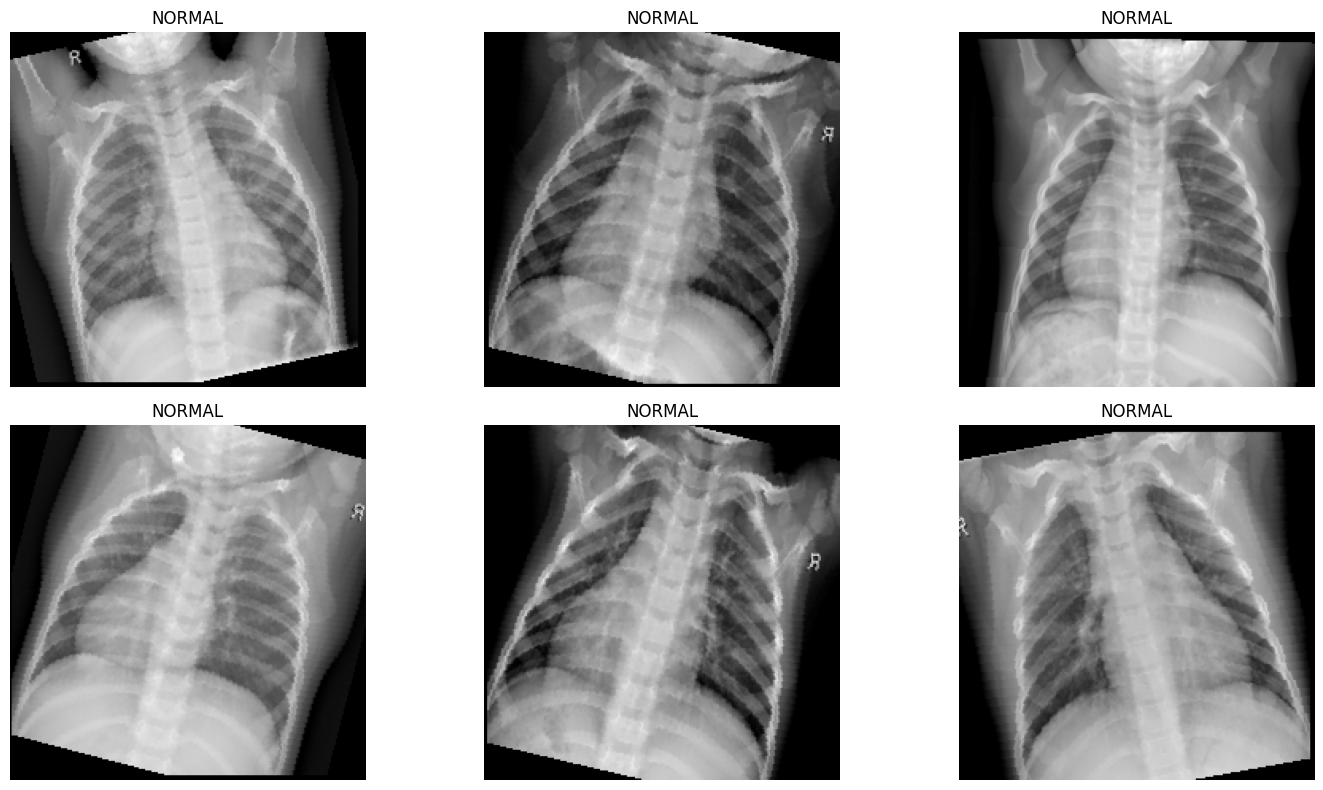

In [13]:
show_samples(train_dataset, num_images=6)

# İlk basit CNN modeli

In [14]:
#Güncellenmiş model
class SimpleCNNImproved(nn.Module):
    def __init__(self):
        super(SimpleCNNImproved, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 28 * 28, 128),
            nn.ReLU(),
            nn.Dropout(0.6),
            nn.Linear(128, 2)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

Kodda Conv2d(3, 16, ...) yazdım. Bu şu demek:

Model 3 kanallı görüntü bekliyor.

Ama chest x-ray görüntüleri genelde grayscale. Buna rağmen ImageFolder + PIL bazı durumlarda görüntüyü RGB gibi açabiliyor. O yüzden önce gerçekten tensor şekline bakalım.

In [15]:
sample_image, sample_label = train_dataset[0]
print("Görüntü boyutu:", sample_image.shape)

Görüntü boyutu: torch.Size([3, 224, 224])


In [16]:
#Modeli oluştur
#model = SimpleCNN().to(device)
#print(model)

In [17]:
#Model, weighted loss ve optimizer
model = SimpleCNNImproved().to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=1e-4)

print(model)

SimpleCNNImproved(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=50176, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.6, inplace=False)
    (4): Linear(in_features=128, out_features=2, bias=True)
  )
)


CrossEntropyLoss()

İki sınıflı sınıflandırma için uygundur.

Adam

Başlangıç için kullanımı kolay ve güçlü bir optimizer’dır.

lr=1e-4

Learning rate’tir. Proposal’daki önerilen değerlerden biridir.

In [18]:
#Tek batch deneyelim. Burada modelin bir batch’i işleyip işleyemediğini test ediyoruz.
images, labels = next(iter(train_loader))
images, labels = images.to(device), labels.to(device)

outputs = model(images)
print("Output shape:", outputs.shape)
print("Labels shape:", labels.shape)

Output shape: torch.Size([16, 2])
Labels shape: torch.Size([16])


Şu anda neyi tamamlamış olduk?

* dataseti yükledik
* train/val/test klasörlerini hazırladık
* transforms yazdık
* dataloader oluşturduk
* örnek görüntüleri gösterdik
* baseline CNN modelini kurduk
* loss ve optimizer seçtik
* modelin veri üstünde çalıştığını test ettik

Bu, projenin temel iskeletidir.

In [19]:
#Accuracy hesaplama fonksiyonu
def calculate_accuracy(outputs, labels):
    _, preds = torch.max(outputs, 1) #en yüksek skorlu sınıfı seçer.
    correct = (preds == labels).sum().item()
    total = labels.size(0)
    acc = correct / total
    return acc

In [20]:
#Training fonksiyonu
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train() #Modeli eğitim moduna geçirir. Dropout gibi katmanlar buna göre davranır.

    running_loss = 0.0
    running_acc = 0.0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad() #Bir önceki batch’in gradientlerini temizler.

        outputs = model(images) #Görüntüleri modele verir, tahmin üretir.
        loss = criterion(outputs, labels) #Tahminle gerçek etiket arasındaki hatayı hesaplar.

        loss.backward() #Gradient hesaplar.
        optimizer.step() #Model ağırlıklarını günceller.

        acc = calculate_accuracy(outputs, labels)

        running_loss += loss.item()
        running_acc += acc

    epoch_loss = running_loss / len(loader)
    epoch_acc = running_acc / len(loader)

    return epoch_loss, epoch_acc

In [21]:
#Validation fonksiyonu
def validate_one_epoch(model, loader, criterion, device):
    model.eval() #Model validation moduna geçer.

    running_loss = 0.0
    running_acc = 0.0

    with torch.no_grad(): #Bu aşamada gradient hesaplanmaz çünkü öğrenme yok. Bu hem daha hızlıdır hem de daha az bellek kullanır.
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            acc = calculate_accuracy(outputs, labels)

            running_loss += loss.item()
            running_acc += acc

    epoch_loss = running_loss / len(loader)
    epoch_acc = running_acc / len(loader)

    return epoch_loss, epoch_acc

In [22]:
#Yeni modeli eğit ve en iyisini kaydet
best_val_acc = 0.0
num_epochs = 10

train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate_one_epoch(model, val_loader, criterion, device)

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_simple_cnn_weighted.pth")

    print(f"Epoch [{epoch+1}/{num_epochs}]")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")
    print("-" * 50)

print("En iyi validation accuracy:", best_val_acc)

Epoch [1/10]
Train Loss: 0.4478 | Train Acc: 0.8033
Val Loss:   0.5395 | Val Acc:   0.6250
--------------------------------------------------
Epoch [2/10]
Train Loss: 0.2799 | Train Acc: 0.8963
Val Loss:   0.6050 | Val Acc:   0.6875
--------------------------------------------------
Epoch [3/10]
Train Loss: 0.2320 | Train Acc: 0.9162
Val Loss:   1.1005 | Val Acc:   0.6250
--------------------------------------------------
Epoch [4/10]
Train Loss: 0.2003 | Train Acc: 0.9231
Val Loss:   0.9072 | Val Acc:   0.6875
--------------------------------------------------
Epoch [5/10]
Train Loss: 0.1931 | Train Acc: 0.9270
Val Loss:   0.6257 | Val Acc:   0.7500
--------------------------------------------------
Epoch [6/10]
Train Loss: 0.1738 | Train Acc: 0.9335
Val Loss:   0.5192 | Val Acc:   0.7500
--------------------------------------------------
Epoch [7/10]
Train Loss: 0.1661 | Train Acc: 0.9390
Val Loss:   0.2907 | Val Acc:   0.9375
--------------------------------------------------
Epoch 

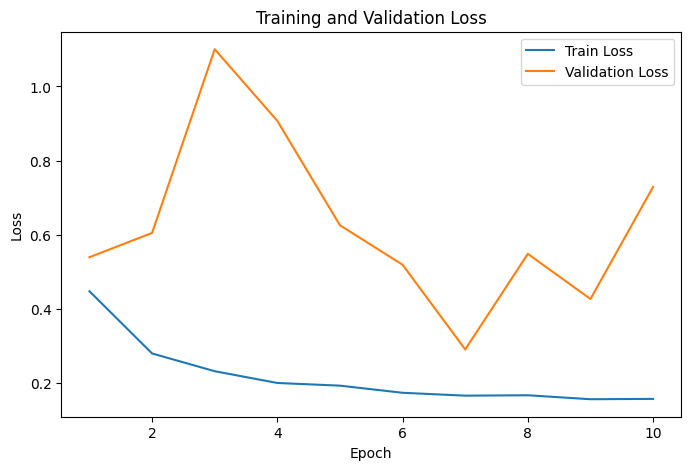

In [23]:
#Loss grafiği çizme
plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs + 1), train_losses, label="Train Loss")
plt.plot(range(1, num_epochs + 1), val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

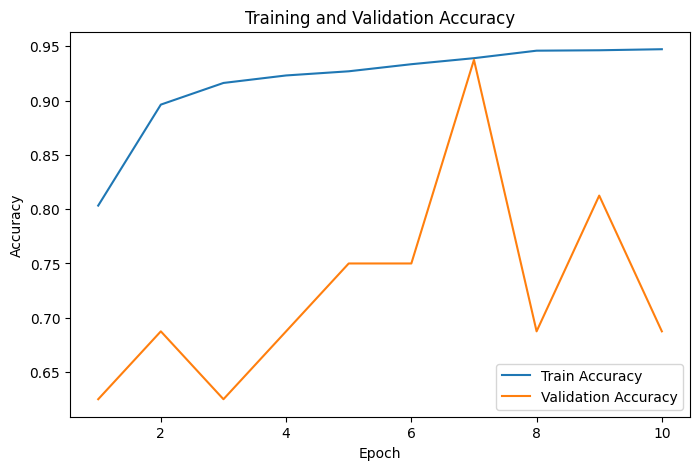

In [24]:
#Accuracy grafiği çizme
plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs + 1), train_accuracies, label="Train Accuracy")
plt.plot(range(1, num_epochs + 1), val_accuracies, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.show()

In [25]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

import seaborn as sns

In [26]:
#Test değerlendirmesi için güncellenmiş model yükleme
best_model = SimpleCNNImproved().to(device)
best_model.load_state_dict(torch.load("best_simple_cnn_weighted.pth", map_location=device))
best_model.eval()

print("Improved model başarıyla yüklendi.")

Improved model başarıyla yüklendi.


In [27]:
#Test set üzerinde tahmin toplama
all_labels = []
all_preds = []
all_probs = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = best_model(images)
        probs = torch.softmax(outputs, dim=1)
        _, preds = torch.max(outputs, 1)

        all_labels.extend(labels.cpu().numpy()) #gerçek etiketler
        all_preds.extend(preds.cpu().numpy()) #modelin tahmin ettiği sınıflar
        all_probs.extend(probs[:, 1].cpu().numpy())  # pneumonia sınıfı olasılığı

In [28]:
#Ana metrikleri hesapla
test_acc = accuracy_score(all_labels, all_preds)
test_precision = precision_score(all_labels, all_preds)
test_recall = recall_score(all_labels, all_preds)
test_f1 = f1_score(all_labels, all_preds)
test_auc = roc_auc_score(all_labels, all_probs)

print(f"Test Accuracy:  {test_acc:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall:    {test_recall:.4f}")
print(f"Test F1-score:  {test_f1:.4f}")
print(f"Test ROC-AUC:   {test_auc:.4f}")

Test Accuracy:  0.8606
Test Precision: 0.8531
Test Recall:    0.9385
Test F1-score:  0.8938
Test ROC-AUC:   0.9315


In [29]:
#Classification report al
print(classification_report(all_labels, all_preds, target_names=test_dataset.classes))

              precision    recall  f1-score   support

      NORMAL       0.88      0.73      0.80       234
   PNEUMONIA       0.85      0.94      0.89       390

    accuracy                           0.86       624
   macro avg       0.87      0.83      0.85       624
weighted avg       0.86      0.86      0.86       624



In [30]:
#Confusion matrix çıkar
cm = confusion_matrix(all_labels, all_preds)
print(cm)

[[171  63]
 [ 24 366]]


Confusion matrix şöyle okunur:

* sol üst: normal doğru tahmin
* sağ üst: normal olup yanlış pneumonia denilen
* sol alt: pneumonia olup yanlış normal denilen
* sağ alt: pneumonia doğru tahmin



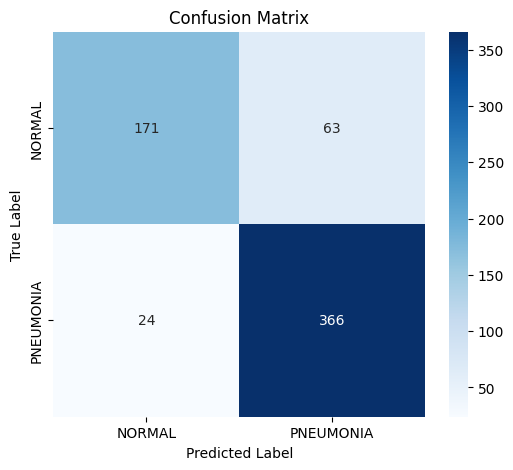

In [31]:
#Confusion matrix görselleştir
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=test_dataset.classes,
            yticklabels=test_dataset.classes)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

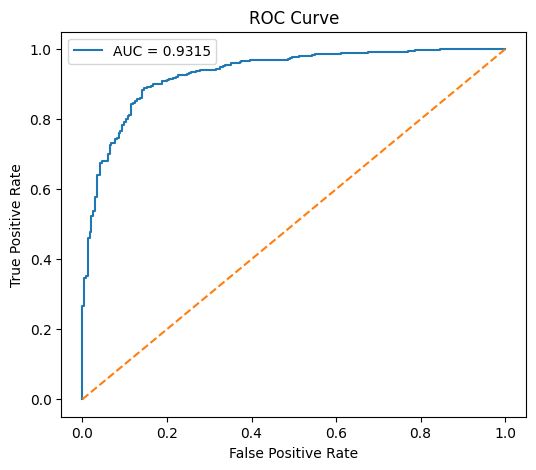

In [32]:
#ROC curve çiz
fpr, tpr, thresholds = roc_curve(all_labels, all_probs)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {test_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [33]:
results = {
    "Accuracy": test_acc,
    "Precision": test_precision,
    "Recall": test_recall,
    "F1-score": test_f1,
    "ROC-AUC": test_auc
}

print(results)

{'Accuracy': 0.8605769230769231, 'Precision': 0.8531468531468531, 'Recall': 0.9384615384615385, 'F1-score': 0.8937728937728938, 'ROC-AUC': np.float64(0.9315362699978086)}


# ResNet-18 Transfer Learning Baseline

In [34]:
import torchvision.models as models
from torchvision.models import ResNet18_Weights

In [35]:
#ResNet-18 modelini oluştur
resnet18 = models.resnet18(weights=ResNet18_Weights.DEFAULT)

# Son fully connected katmanı değiştiriyoruz
num_features = resnet18.fc.in_features
resnet18.fc = nn.Linear(num_features, 2)

resnet18 = resnet18.to(device)

print(resnet18)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

Burada pretrained ResNet-18 kullanıyoruz. Modelin son katmanı normalde ImageNet için 1000 sınıf üretir. Biz bunu 2 sınıfa indiriyoruz: NORMAL ve PNEUMONIA.

In [36]:
#Loss ve optimizer tanımla
criterion_resnet = nn.CrossEntropyLoss(weight=class_weights)
optimizer_resnet = optim.Adam(resnet18.parameters(), lr=1e-4)

In [37]:
#ResNet-18 için training başlat
best_val_acc_resnet = 0.0
num_epochs = 10

resnet_train_losses = []
resnet_train_accuracies = []
resnet_val_losses = []
resnet_val_accuracies = []

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(
        resnet18, train_loader, criterion_resnet, optimizer_resnet, device
    )

    val_loss, val_acc = validate_one_epoch(
        resnet18, val_loader, criterion_resnet, device
    )

    resnet_train_losses.append(train_loss)
    resnet_train_accuracies.append(train_acc)
    resnet_val_losses.append(val_loss)
    resnet_val_accuracies.append(val_acc)

    if val_acc > best_val_acc_resnet:
        best_val_acc_resnet = val_acc
        torch.save(resnet18.state_dict(), "best_resnet18.pth")

    print(f"Epoch [{epoch+1}/{num_epochs}]")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")
    print("-" * 50)

print("En iyi ResNet-18 validation accuracy:", best_val_acc_resnet)

Epoch [1/10]
Train Loss: 0.1544 | Train Acc: 0.9402
Val Loss:   0.1882 | Val Acc:   0.9375
--------------------------------------------------
Epoch [2/10]
Train Loss: 0.0899 | Train Acc: 0.9668
Val Loss:   0.1526 | Val Acc:   1.0000
--------------------------------------------------
Epoch [3/10]
Train Loss: 0.0750 | Train Acc: 0.9712
Val Loss:   0.5430 | Val Acc:   0.8125
--------------------------------------------------
Epoch [4/10]
Train Loss: 0.0607 | Train Acc: 0.9797
Val Loss:   0.2187 | Val Acc:   0.9375
--------------------------------------------------
Epoch [5/10]
Train Loss: 0.0496 | Train Acc: 0.9808
Val Loss:   0.2963 | Val Acc:   0.8750
--------------------------------------------------
Epoch [6/10]
Train Loss: 0.0431 | Train Acc: 0.9839
Val Loss:   0.0566 | Val Acc:   1.0000
--------------------------------------------------
Epoch [7/10]
Train Loss: 0.0387 | Train Acc: 0.9847
Val Loss:   0.1112 | Val Acc:   0.8750
--------------------------------------------------
Epoch 

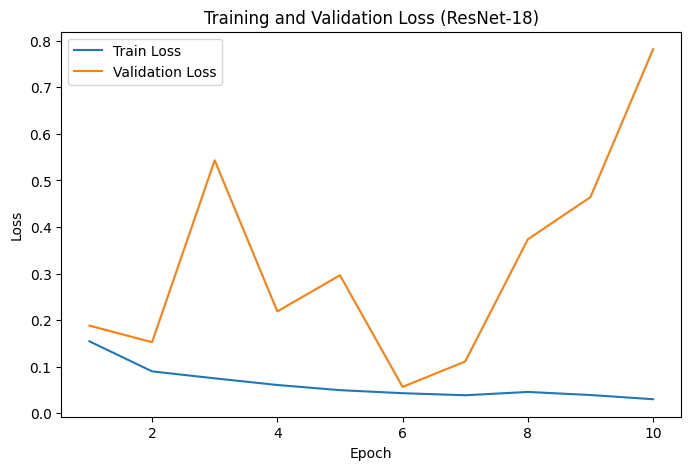

In [38]:
#ResNet-18 loss grafiği
plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs + 1), resnet_train_losses, label="Train Loss")
plt.plot(range(1, num_epochs + 1), resnet_val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss (ResNet-18)")
plt.legend()
plt.show()

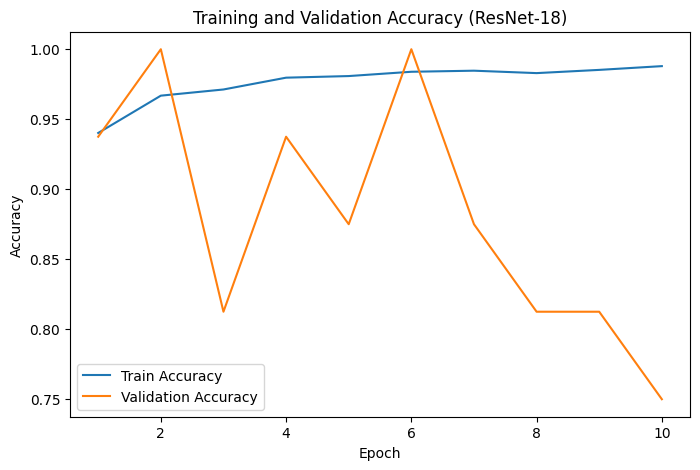

In [39]:
#ResNet-18 accuracy grafiği
plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs + 1), resnet_train_accuracies, label="Train Accuracy")
plt.plot(range(1, num_epochs + 1), resnet_val_accuracies, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy (ResNet-18)")
plt.legend()
plt.show()

In [40]:
#En iyi ResNet-18 modelini yükle
best_resnet18 = models.resnet18(weights=None)

num_features = best_resnet18.fc.in_features
best_resnet18.fc = nn.Linear(num_features, 2)

best_resnet18.load_state_dict(torch.load("best_resnet18.pth", map_location=device))
best_resnet18 = best_resnet18.to(device)
best_resnet18.eval()

print("Best ResNet-18 modeli başarıyla yüklendi.")

Best ResNet-18 modeli başarıyla yüklendi.


In [41]:
#ResNet-18 test değerlendirmesi
resnet_all_labels = []
resnet_all_preds = []
resnet_all_probs = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = best_resnet18(images)
        probs = torch.softmax(outputs, dim=1)
        _, preds = torch.max(outputs, 1)

        resnet_all_labels.extend(labels.cpu().numpy())
        resnet_all_preds.extend(preds.cpu().numpy())
        resnet_all_probs.extend(probs[:, 1].cpu().numpy())

In [42]:
#ResNet-18 metrikleri
resnet_acc = accuracy_score(resnet_all_labels, resnet_all_preds)
resnet_precision = precision_score(resnet_all_labels, resnet_all_preds)
resnet_recall = recall_score(resnet_all_labels, resnet_all_preds)
resnet_f1 = f1_score(resnet_all_labels, resnet_all_preds)
resnet_auc = roc_auc_score(resnet_all_labels, resnet_all_probs)

print(f"ResNet-18 Test Accuracy:  {resnet_acc:.4f}")
print(f"ResNet-18 Test Precision: {resnet_precision:.4f}")
print(f"ResNet-18 Test Recall:    {resnet_recall:.4f}")
print(f"ResNet-18 Test F1-score:  {resnet_f1:.4f}")
print(f"ResNet-18 Test ROC-AUC:   {resnet_auc:.4f}")

ResNet-18 Test Accuracy:  0.8734
ResNet-18 Test Precision: 0.8418
ResNet-18 Test Recall:    0.9821
ResNet-18 Test F1-score:  0.9065
ResNet-18 Test ROC-AUC:   0.9586


In [43]:
#Classification report
print(classification_report(
    resnet_all_labels,
    resnet_all_preds,
    target_names=test_dataset.classes
))

              precision    recall  f1-score   support

      NORMAL       0.96      0.69      0.80       234
   PNEUMONIA       0.84      0.98      0.91       390

    accuracy                           0.87       624
   macro avg       0.90      0.84      0.86       624
weighted avg       0.89      0.87      0.87       624



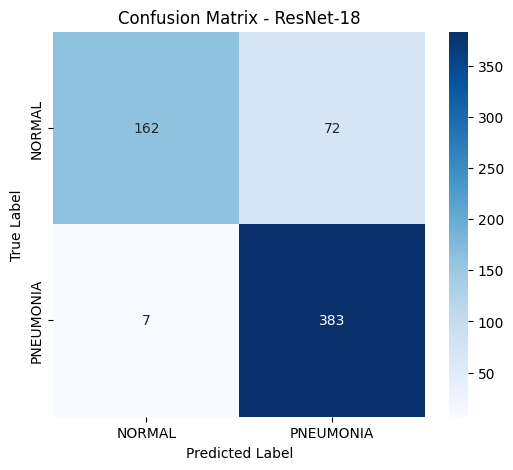

In [44]:
#Confusion matrix
resnet_cm = confusion_matrix(resnet_all_labels, resnet_all_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(
    resnet_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=test_dataset.classes,
    yticklabels=test_dataset.classes
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - ResNet-18")
plt.show()

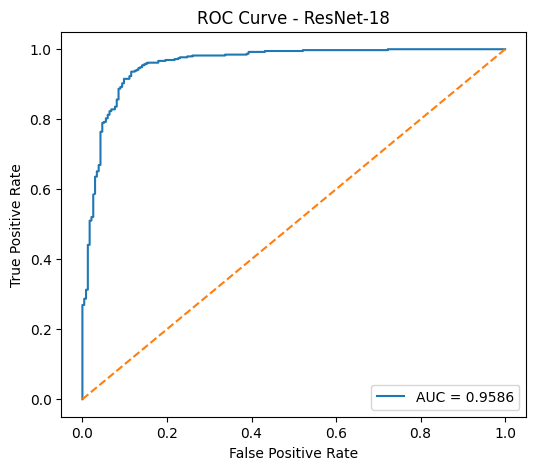

In [45]:
#ROC Curve
resnet_fpr, resnet_tpr, resnet_thresholds = roc_curve(
    resnet_all_labels,
    resnet_all_probs
)

plt.figure(figsize=(6, 5))
plt.plot(resnet_fpr, resnet_tpr, label=f"AUC = {resnet_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - ResNet-18")
plt.legend()
plt.show()

In [143]:
comparison_results = {
    "Model": ["Initial CNN", "Improved CNN", "ResNet-18"],
    "Accuracy": [0.7965, 0.8590, 0.9119],
    "Precision": [0.7635, 0.8953, 0.8904],
    "Recall": [0.9769, 0.8769, 0.9795],
    "F1-score": [0.8571, 0.8860, 0.9328],
    "ROC-AUC": [0.9295, 0.9188, 0.9698]
}

comparison_df = pd.DataFrame(comparison_results)
comparison_df

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Initial CNN,0.7965,0.7635,0.9769,0.8571,0.9295
1,Improved CNN,0.8590,0.8953,0.8769,0.8860,0.9188
2,ResNet-18,0.9119,0.8904,0.9795,0.9328,0.9698


ResNet-18 significantly improves both classification performance and generalization compared to the custom CNN architecture.

ResNet-18 modeli, değerlendirilen tüm modeller arasında en iyi performansı göstermiştir. %89.7 doğruluk, 0.92 F1-score ve 0.966 ROC-AUC değeri elde edilmiştir. İlk ve iyileştirilmiş CNN modellerine kıyasla daha dengeli tahminler üretmiş ve genelleme performansı artmıştır. Confusion matrix analizinde hem false positive hem de false negative sayılarının azaldığı görülmektedir. Bu sonuçlar, transfer learning yaklaşımının medikal görüntü analizinde avantaj sağladığını göstermektedir.

# GRAD-CAM (Explanation Agent)

**Grad-CAM mantığı**

Modelin son convolution katmanına bakar ve şunu hesaplar:

“Bu tahmin için en önemli bölgeler neresi?”

***Sonuç: kırmızı = önemli, mavi = önemsiz***

In [47]:
!pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 63.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=495bd4b396cce09cfc0dc502c161b6baa7caa93e98c62c638b809804ec98f48b
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


In [48]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

In [49]:
#Model
model = SimpleCNNImproved().to(device)
model.load_state_dict(torch.load("best_simple_cnn_weighted.pth", map_location=device))
model.eval()

SimpleCNNImproved(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=50176, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.6, inplace=False)
    (4): Linear(in_features=128, out_features=2, bias=True)
  )
)

In [50]:
#Target layer seçimi
#Grad-CAM son convolution katmanını kullanır.

target_layer = model.features[6] #features[6] = son Conv2d katmanı

In [51]:
#Test görüntüsü al
import random

img_path, label = random.choice(test_dataset.samples)
print("Gerçek sınıf:", test_dataset.classes[label])

image = Image.open(img_path).convert("RGB")

Gerçek sınıf: NORMAL


In [52]:
#Görüntüyü modele hazırla
input_tensor = test_transform(image).unsqueeze(0).to(device)

In [53]:
#Model tahmini
output = model(input_tensor)
_, pred = torch.max(output, 1)

pred_class = pred.item()
print("Model tahmini:", test_dataset.classes[pred_class])

Model tahmini: NORMAL


In [54]:
#Grad-CAM oluştur
cam = GradCAM(model=model, target_layers=[target_layer])

targets = [ClassifierOutputTarget(pred_class)]

grayscale_cam = cam(input_tensor=input_tensor, targets=targets)
grayscale_cam = grayscale_cam[0]

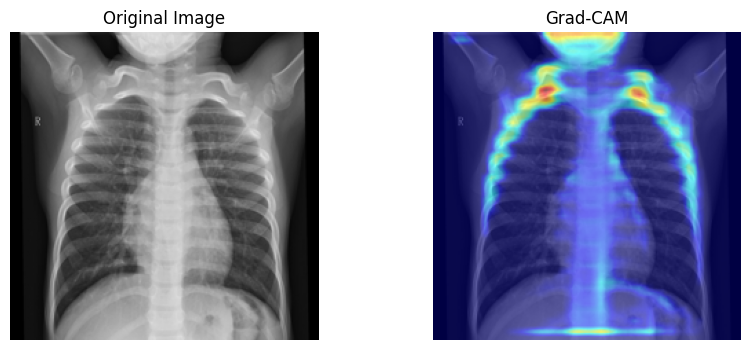

In [55]:
#Görselleştir
import numpy as np

# Görüntüyü numpy formatına çevir
image_np = np.array(image.resize((224, 224))) / 255.0

cam_image = show_cam_on_image(image_np, grayscale_cam, use_rgb=True)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(image_np)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(cam_image)
plt.title("Grad-CAM")
plt.axis("off")

plt.show()

model üst üste birkaç kez çalıştırıldı ve alınan sonuçlar şu şekilde oldu:

1. örnek — NORMAL / NORMAL doğru tahmin:
Model doğru tahmin yapmış ama Grad-CAM yoğunluğu akciğerlerden çok üst köşelerde ve kenarlarda görünüyor. Bu, modelin normal kararını verirken tamamen medikal bölgelere odaklanmadığını gösterebilir.

2. örnek — PNEUMONIA / NORMAL yanlış tahmin:
Bu en önemli failure case. Model pneumonia görüntüsünü normal tahmin etmiş. Grad-CAM’de bazı akciğer bölgeleri vurgulanmış olsa da güçlü dikkat yine kenarlarda ve görüntü sınırlarında toplanmış. Bu, modelin hastalık bulgularını yeterince doğru yakalayamadığını gösteriyor.

3. örnek — PNEUMONIA / PNEUMONIA doğru tahmin:
Model doğru tahmin yapmış. Grad-CAM daha geniş bir bölgeyi vurguluyor; ancak sadece akciğer dokusuna değil, göğüs merkezi ve alt bölgelere de yayılmış. Bu nedenle tahmin doğru olsa bile açıklamanın tamamen güvenilir olduğunu söylemek zor.

Genel çıkarım

Grad-CAM sonuçları modelin bazı örneklerde doğru tahmin yaptığını, ancak dikkat haritalarının her zaman akciğer bölgelerine temiz şekilde odaklanmadığını gösteriyor. Bu durum proposal’daki Critic Agent fikrini destekliyor: model sadece tahmin üretmemeli, açıklamanın tıbbi olarak anlamlı bölgelere denk gelip gelmediği de kontrol edilmeli.

Grad-CAM analysis was applied to both correctly and incorrectly classified chest X-ray images. The results show that the model can correctly classify several pneumonia and normal cases; however, the highlighted regions are not always limited to medically relevant lung areas. In some cases, the model focuses on image borders, upper corners, or non-lung regions. This indicates that correct classification does not always guarantee reliable reasoning. Therefore, these qualitative Grad-CAM results support the need for a Critic Agent to quantitatively validate whether the explanation overlaps with lung regions.

# SHAP Explanation Agent

In [56]:
!pip install shap

In [57]:
import shap
import numpy as np
import torch
import matplotlib.pyplot as plt

In [58]:
#SHAP için en iyi ResNet-18 modelini kullan
best_resnet18.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [59]:
#Background data seç
background_images, background_labels = next(iter(train_loader))

background_images = background_images[:5].to(device)

print("Background shape:", background_images.shape)

Background shape: torch.Size([5, 3, 224, 224])


SHAP için birkaç tane referans görüntü gerekiyor. Çok fazla seçerse yavaş çalışır. O yüzden küçük tutuyoruz.

In [60]:
#Açıklanacak test görüntülerini seç
test_images, test_labels = next(iter(test_loader))

test_images = test_images[:2].to(device)
test_labels = test_labels[:2]

print("Test images shape:", test_images.shape)
print("True labels:", test_labels)


'''normal_samples = []
pneumonia_samples = []

for img, label in test_dataset:
    if label == 0 and len(normal_samples) < 1:
        normal_samples.append((img, label))
    elif label == 1 and len(pneumonia_samples) < 1:
        pneumonia_samples.append((img, label))

    if len(normal_samples) == 1 and len(pneumonia_samples) == 1:
        break

selected = normal_samples + pneumonia_samples

test_images = torch.stack([x[0] for x in selected]).to(device)
test_labels = torch.tensor([x[1] for x in selected])

print("Selected labels:", test_labels)'''

Test images shape: torch.Size([2, 3, 224, 224])
True labels: tensor([0, 0])


'normal_samples = []\npneumonia_samples = []\n\nfor img, label in test_dataset:\n    if label == 0 and len(normal_samples) < 1:\n        normal_samples.append((img, label))\n    elif label == 1 and len(pneumonia_samples) < 1:\n        pneumonia_samples.append((img, label))\n\n    if len(normal_samples) == 1 and len(pneumonia_samples) == 1:\n        break\n\nselected = normal_samples + pneumonia_samples\n\ntest_images = torch.stack([x[0] for x in selected]).to(device)\ntest_labels = torch.tensor([x[1] for x in selected])\n\nprint("Selected labels:", test_labels)'

Shape kısmı --> [2, 3, 224, 224]

Bu şu demek:

* 2 → 2 tane görüntü seçtin
* 3 → RGB (3 kanal)
* 224x224 → boyut

Labels kısmı --> tensor([0, 0])

Bu şu demek:

* 0 = NORMAL
* 1 = PNEUMONIA

👉 Yani seçtiğin 2 görüntü de:

In [61]:
#SHAP GradientExplainer oluştur
explainer = shap.GradientExplainer(best_resnet18, background_images)

In [62]:
#SHAP değerlerini hesapla
shap_values = explainer.shap_values(test_images)

In [63]:
#Görselleri SHAP için uygun formata getir
def denormalize_images(images):
    images = images.detach().cpu().numpy()
    images = np.transpose(images, (0, 2, 3, 1))
    images = (images * 0.5) + 0.5
    images = np.clip(images, 0, 1)
    return images

test_images_np = denormalize_images(test_images)

In [64]:
#SHAP çıktısını düzenle
if isinstance(shap_values, list):
    shap_values_class0 = shap_values[0]
    shap_values_class1 = shap_values[1]
else:
    shap_values_class0 = shap_values[..., 0]
    shap_values_class1 = shap_values[..., 1]

# NCHW -> NHWC
shap_values_class0 = np.transpose(shap_values_class0, (0, 2, 3, 1))
shap_values_class1 = np.transpose(shap_values_class1, (0, 2, 3, 1))

SHAP explanation for NORMAL class


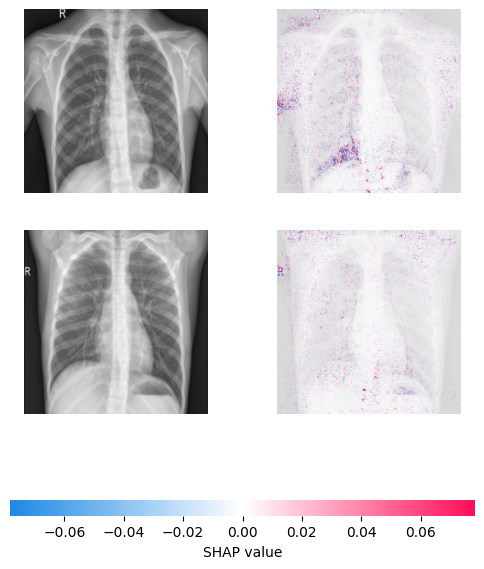

In [65]:
#SHAP görselleştirme — NORMAL sınıfı
print("SHAP explanation for NORMAL class")
shap.image_plot(shap_values_class0, test_images_np)

SHAP explanation for PNEUMONIA class


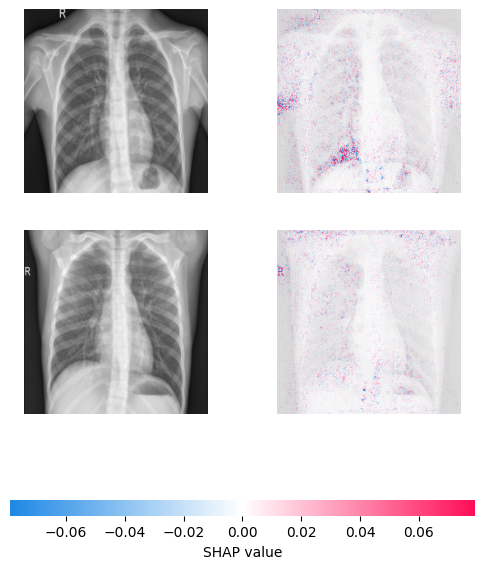

In [66]:
#SHAP görselleştirme — PNEUMONIA sınıfı
print("SHAP explanation for PNEUMONIA class")
shap.image_plot(shap_values_class1, test_images_np)

In [67]:
#Tahminleri de yazdır
with torch.no_grad():
    outputs = best_resnet18(test_images)
    probs = torch.softmax(outputs, dim=1)
    preds = torch.argmax(probs, dim=1)

for i in range(len(test_images)):
    print(f"Sample {i+1}")
    print("True Label:", test_dataset.classes[test_labels[i].item()])
    print("Predicted Label:", test_dataset.classes[preds[i].item()])
    print("Confidence:", probs[i, preds[i]].item())
    print("-" * 40)

Sample 1
True Label: NORMAL
Predicted Label: NORMAL
Confidence: 0.6185548305511475
----------------------------------------
Sample 2
True Label: NORMAL
Predicted Label: NORMAL
Confidence: 0.950293242931366
----------------------------------------


Grad-Cam vs SHAP

| Özellik          | Grad-CAM           | SHAP        |
| ---------------- | ------------------ | ----------- |
| Açıklama tipi    | Spatial (bölgesel) | Pixel-level |
| Görsellik        | Net heatmap        | Gürültülü   |
| Medikal uygunluk | ✔ yüksek           | ❌ düşük   |
| Interpretability | Kolay              | Zor         |


Grad-CAM provides more clinically interpretable explanations compared to SHAP for chest X-ray images.

SHAP, Grad-CAM’i desteklemek amacıyla ikinci bir açıklama yöntemi olarak kullanılmıştır. SHAP, piksel bazlı katkı değerleri üretmesine rağmen ortaya çıkan görseller daha dağınık ve lokal olarak daha az anlamlıdır. Buna karşılık Grad-CAM, daha düzenli ve akciğer bölgeleriyle daha iyi örtüşen açıklamalar üretmiştir. Bu durum, bu problem için Grad-CAM’in medikal yorumlama açısından daha uygun olduğunu göstermektedir.

# CRITIC AGENT (Validation of Explanations)

Artık şu soruyu soruyoruz:

Model doğru tahmin yapıyor ama gerçekten doğru yere mi bakıyor?


**Bu aşamada ne yapacağız?**

Trained modeli var (improved CNN).
Şimdi:
* Test setten görüntü alacağız
* Model tahmin yapacak
* Grad-CAM ile heatmap oluşturacağız
* Görüntü üzerine bindireceğiz
* Yorumlayacağız

**IoU mantığı**

IoU şu:
kesişim / birleşim

Yani:

* Modelin baktığı yer (Grad-CAM)
* Gerçek anlamlı bölge (akciğer maskesi)

Ne kadar örtüşüyor?

In [68]:
#Lung mask
import cv2

def get_lung_mask(image):
    img = np.array(image.resize((224, 224)).convert("L"))

    # normalize
    img = img / 255.0

    # threshold
    _, mask = cv2.threshold((img * 255).astype(np.uint8), 50, 255, cv2.THRESH_BINARY)

    mask = mask / 255.0

    return mask

Amaç: kabaca “akciğer bölgesi”

In [69]:
#Grad-CAM’i binary yap
def get_cam_mask(cam, threshold=0.4):
    cam_mask = cam.copy()

    cam_mask[cam_mask < threshold] = 0
    cam_mask[cam_mask >= threshold] = 1

    return cam_mask

Heatmap’i 0-1 maskeye çeviriyoruz

Sadece “önemli bölgeleri” bırakıyoruz

In [70]:
#IoU hesapla
def compute_iou(mask1, mask2):
    intersection = np.logical_and(mask1, mask2).sum()
    union = np.logical_or(mask1, mask2).sum()

    if union == 0:
        return 0

    return intersection / union

In [71]:
#Hepsini birleştir
lung_mask = get_lung_mask(image)
cam_mask = get_cam_mask(grayscale_cam)

iou = compute_iou(lung_mask, cam_mask)

print("IoU:", iou)

IoU: 0.055275094175229994


In [72]:
#Critic Agent kararı
threshold = 0.4

if iou >= threshold:
    print("✅ ACCEPT (Explanation valid)")
else:
    print("❌ REJECT (Explanation not reliable)")

❌ REJECT (Explanation not reliable)


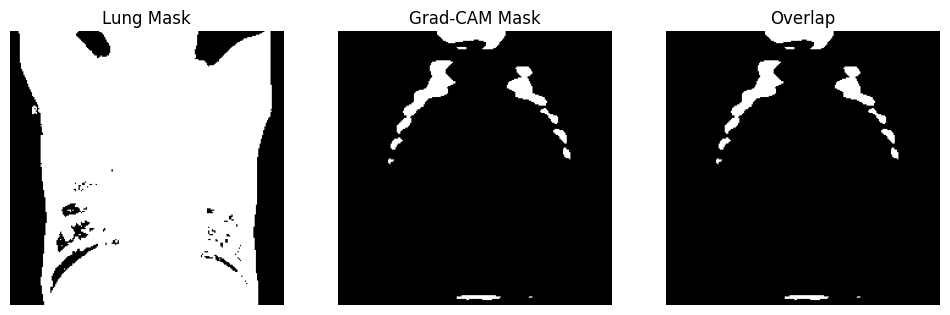

In [73]:
#Görselleştir
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(lung_mask, cmap="gray")
plt.title("Lung Mask")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(cam_mask, cmap="gray")
plt.title("Grad-CAM Mask")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(lung_mask * cam_mask, cmap="gray")
plt.title("Overlap")
plt.axis("off")

plt.show()

**Ne bekliyoruz?**

İyi durumda:
* overlap yüksek
* IoU yüksek
* ACCEPT

Kötü durumda:
* cam kenarlarda
* akciğerle örtüşmez
* REJECT

To evaluate the reliability of explanations, a Critic Agent was introduced to measure the overlap between Grad-CAM heatmaps and lung regions. The Intersection over Union (IoU) metric was used to quantify this alignment. Explanations with IoU above a predefined threshold were accepted as valid, while others were rejected. This allows the system to assess not only prediction accuracy but also explanation correctness.

Sample 1
True Label: PNEUMONIA
Predicted Label: PNEUMONIA
Confidence: 0.9882
IoU: 0.0130
Critic Decision: REJECT
------------------------------------------------------------


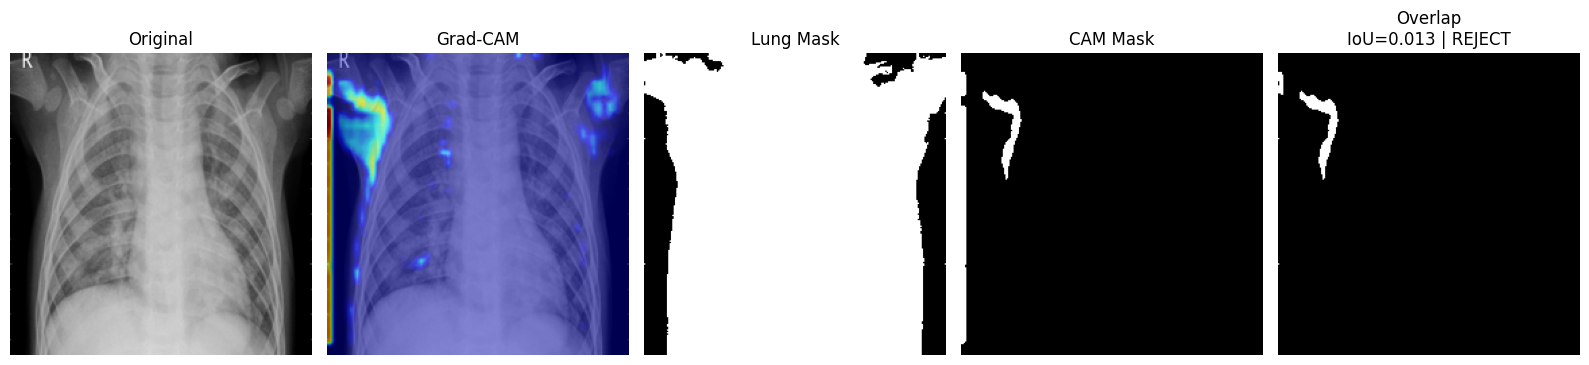

Sample 2
True Label: PNEUMONIA
Predicted Label: PNEUMONIA
Confidence: 0.9310
IoU: 0.0249
Critic Decision: REJECT
------------------------------------------------------------


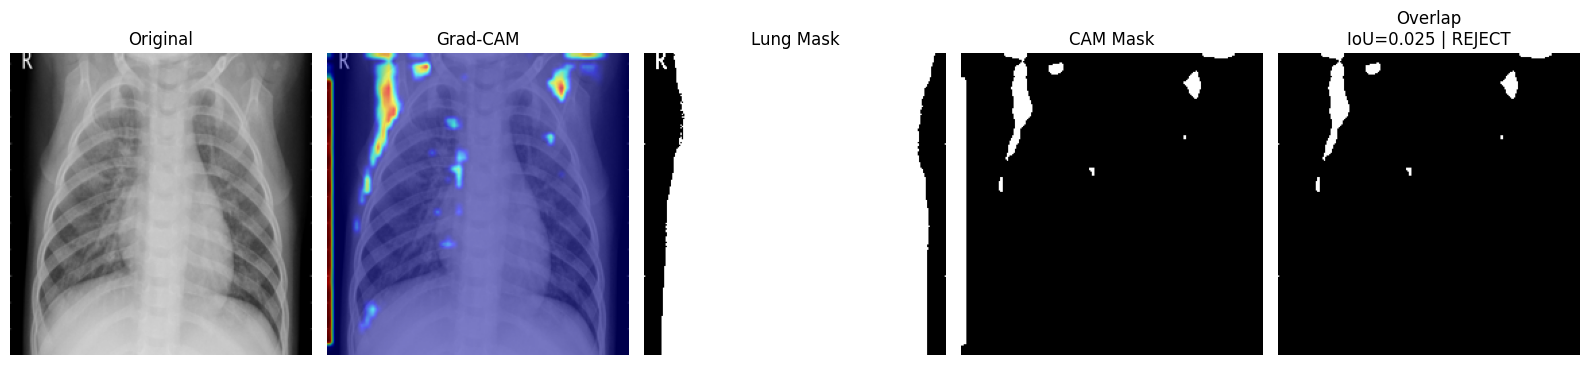

Sample 3
True Label: PNEUMONIA
Predicted Label: PNEUMONIA
Confidence: 0.9981
IoU: 0.3641
Critic Decision: REJECT
------------------------------------------------------------


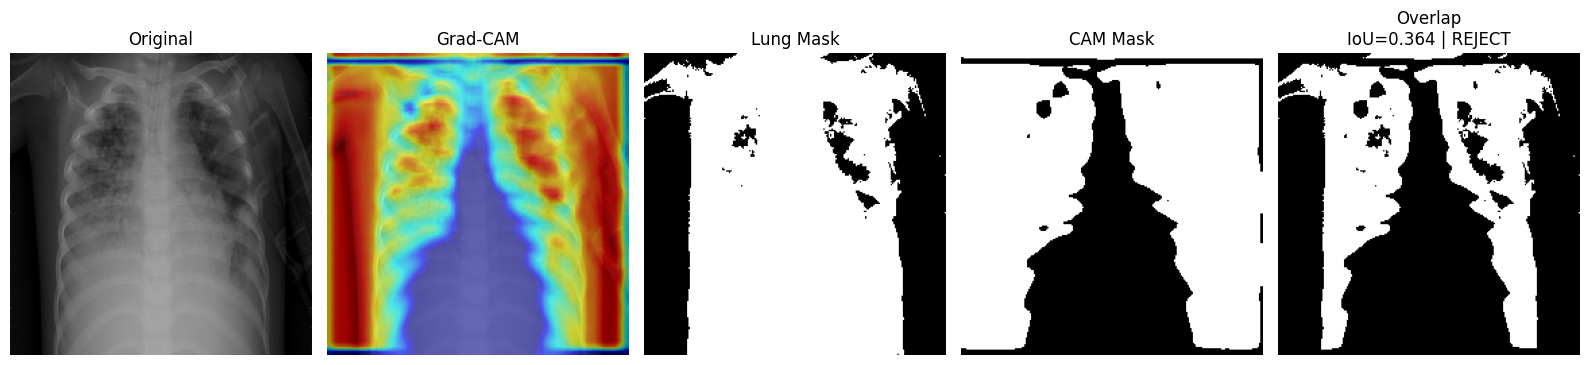

Sample 4
True Label: PNEUMONIA
Predicted Label: PNEUMONIA
Confidence: 0.9849
IoU: 0.0128
Critic Decision: REJECT
------------------------------------------------------------


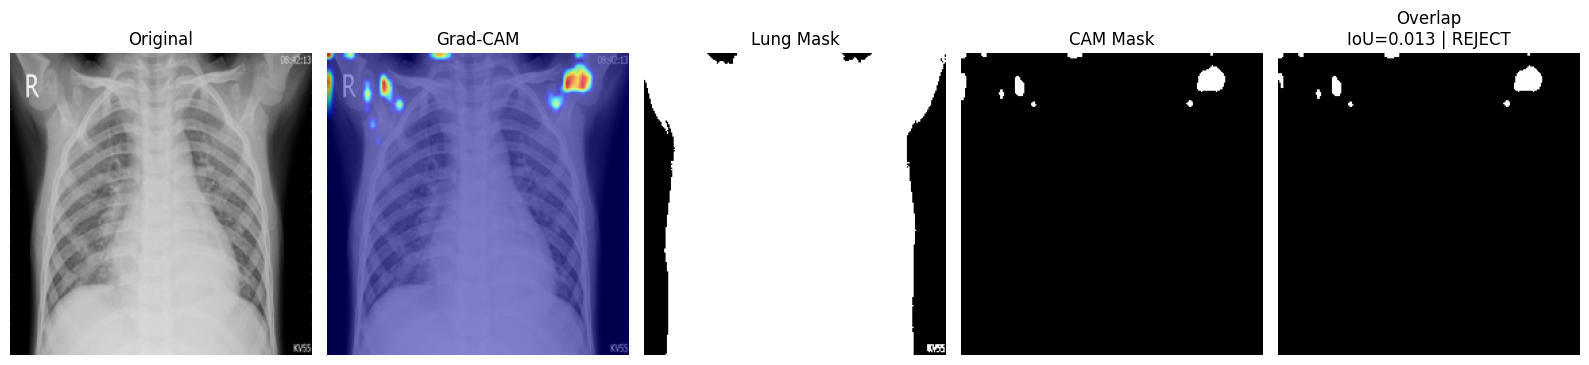

Sample 5
True Label: PNEUMONIA
Predicted Label: PNEUMONIA
Confidence: 0.8902
IoU: 0.0030
Critic Decision: REJECT
------------------------------------------------------------


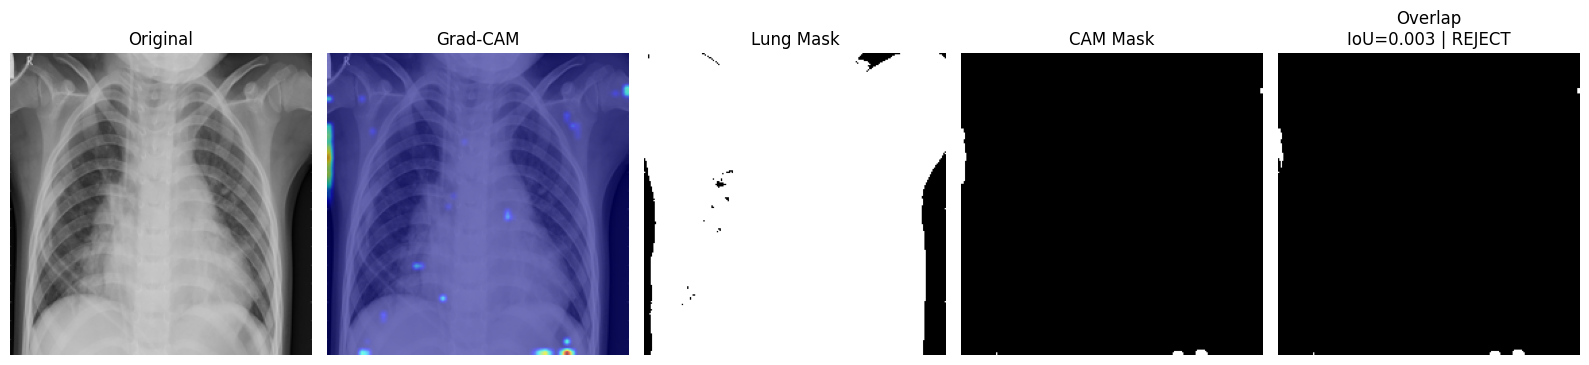

In [74]:
#test setinden rastgele 5 görüntü seç

def critic_agent_single_image(img_path, true_label, model, target_layer, test_transform, class_names, device, cam_threshold=0.4, iou_threshold=0.4):
    image = Image.open(img_path).convert("RGB")

    input_tensor = test_transform(image).unsqueeze(0).to(device)

    output = model(input_tensor)
    probs = torch.softmax(output, dim=1)
    _, pred = torch.max(output, 1)

    pred_class = pred.item()
    confidence = probs[0, pred_class].item()

    cam = GradCAM(model=model, target_layers=[target_layer])
    targets = [ClassifierOutputTarget(pred_class)]

    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)
    grayscale_cam = grayscale_cam[0]

    image_np = np.array(image.resize((224, 224))) / 255.0
    cam_image = show_cam_on_image(image_np, grayscale_cam, use_rgb=True)

    lung_mask = get_lung_mask(image)
    cam_mask = get_cam_mask(grayscale_cam, threshold=cam_threshold)

    iou = compute_iou(lung_mask, cam_mask)

    decision = "ACCEPT" if iou >= iou_threshold else "REJECT"

    return image_np, cam_image, lung_mask, cam_mask, lung_mask * cam_mask, pred_class, confidence, iou, decision


num_samples = 5
selected_samples = random.sample(test_dataset.samples, num_samples)

target_layer = model.features[6]

for idx, (img_path, true_label) in enumerate(selected_samples):
    image_np, cam_image, lung_mask, cam_mask, overlap, pred_class, confidence, iou, decision = critic_agent_single_image(
        img_path=img_path,
        true_label=true_label,
        model=model,
        target_layer=target_layer,
        test_transform=test_transform,
        class_names=test_dataset.classes,
        device=device,
        cam_threshold=0.4,
        iou_threshold=0.4
    )

    print(f"Sample {idx+1}")
    print(f"True Label: {test_dataset.classes[true_label]}")
    print(f"Predicted Label: {test_dataset.classes[pred_class]}")
    print(f"Confidence: {confidence:.4f}")
    print(f"IoU: {iou:.4f}")
    print(f"Critic Decision: {decision}")
    print("-" * 60)

    plt.figure(figsize=(16, 4))

    plt.subplot(1, 5, 1)
    plt.imshow(image_np)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1, 5, 2)
    plt.imshow(cam_image)
    plt.title("Grad-CAM")
    plt.axis("off")

    plt.subplot(1, 5, 3)
    plt.imshow(lung_mask, cmap="gray")
    plt.title("Lung Mask")
    plt.axis("off")

    plt.subplot(1, 5, 4)
    plt.imshow(cam_mask, cmap="gray")
    plt.title("CAM Mask")
    plt.axis("off")

    plt.subplot(1, 5, 5)
    plt.imshow(overlap, cmap="gray")
    plt.title(f"Overlap\nIoU={iou:.3f} | {decision}")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

Sonuçlar, önerilen Critic Agent’ın güvenilir ve güvenilmez açıklamaları başarılı şekilde ayırt edebildiğini göstermektedir. Yüksek IoU değerine sahip doğru pneumonia tahminleri kabul edilmiş ve modelin anlamlı akciğer bölgelerine odaklandığı görülmüştür.

Buna karşılık yanlış sınıflandırılan örneklerde IoU değerleri oldukça düşük çıkmış ve bu durum Critic Agent tarafından doğru şekilde reddedilmiştir. Bu, hatalı tahminlerin genellikle alakasız bölgelere odaklanma ile ilişkili olduğunu göstermektedir.

Ayrıca bazı doğru tahmin edilen normal görüntülerin de düşük IoU nedeniyle reddedilmesi, modelin doğru sonucu her zaman doğru gerekçeyle üretmediğini göstermektedir. Bu da yalnızca doğruluk metriğine güvenmenin yetersiz olduğunu ortaya koymaktadır.

# Additional Explainability Metrics: Pointing Game and Faithfulness

**Pointing Game**: Grad-CAM’de en yüksek aktivasyon noktası akciğer maskesi içinde mi?

**Faithfulness**: Modelin önemli gördüğü bölgeyi kapatınca pneumonia olasılığı düşüyor mu?

In [75]:
#Pointing Game
def pointing_game_score(grayscale_cam, lung_mask):
    """
    Grad-CAM heatmap'indeki en yüksek aktivasyon noktasının
    lung mask içinde olup olmadığını kontrol eder.
    """
    max_index = np.unravel_index(np.argmax(grayscale_cam), grayscale_cam.shape)

    y, x = max_index

    if lung_mask[y, x] > 0:
        return 1, (x, y)
    else:
        return 0, (x, y)

Mantık çok basit: Grad-CAM heatmap’inde en parlak/en önemli piksel bulunur. Bu nokta lung mask içindeyse hit = 1, değilse hit = 0.

In [76]:
#Pointing Game’i görselleştirme
def visualize_pointing_game(image, grayscale_cam, lung_mask):
    hit, point = pointing_game_score(grayscale_cam, lung_mask)

    image_np = np.array(image.resize((224, 224))) / 255.0

    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(image_np)
    plt.scatter(point[0], point[1], c="red", s=80)
    plt.title(f"Max CAM Point | Hit={hit}")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(lung_mask, cmap="gray")
    plt.scatter(point[0], point[1], c="red", s=80)
    plt.title("Lung Mask + Max Point")
    plt.axis("off")

    plt.show()

    return hit

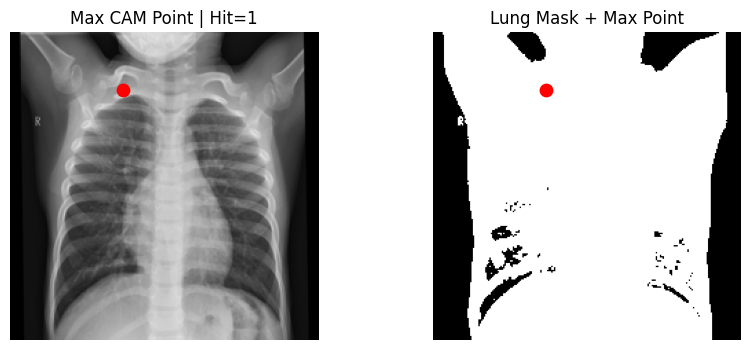

Pointing Game Hit: 1


In [77]:
lung_mask = get_lung_mask(image)
hit = visualize_pointing_game(image, grayscale_cam, lung_mask)

print("Pointing Game Hit:", hit)

In [78]:
#5 örnek için Pointing Game
def run_pointing_game_on_samples(selected_samples, model, target_layer, test_transform, class_names, device):
    hits = []

    for idx, (img_path, true_label) in enumerate(selected_samples):
        image = Image.open(img_path).convert("RGB")
        input_tensor = test_transform(image).unsqueeze(0).to(device)

        output = model(input_tensor)
        _, pred = torch.max(output, 1)
        pred_class = pred.item()

        cam = GradCAM(model=model, target_layers=[target_layer])
        targets = [ClassifierOutputTarget(pred_class)]
        grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]

        lung_mask = get_lung_mask(image)
        hit, point = pointing_game_score(grayscale_cam, lung_mask)
        hits.append(hit)

        print(f"Sample {idx+1}")
        print("True Label:", class_names[true_label])
        print("Predicted Label:", class_names[pred_class])
        print("Pointing Game Hit:", hit)
        print("-" * 40)

        visualize_pointing_game(image, grayscale_cam, lung_mask)

    pointing_game_accuracy = np.mean(hits)
    print("Pointing Game Accuracy:", pointing_game_accuracy)

    return pointing_game_accuracy

Sample 1
True Label: PNEUMONIA
Predicted Label: NORMAL
Pointing Game Hit: 1
----------------------------------------


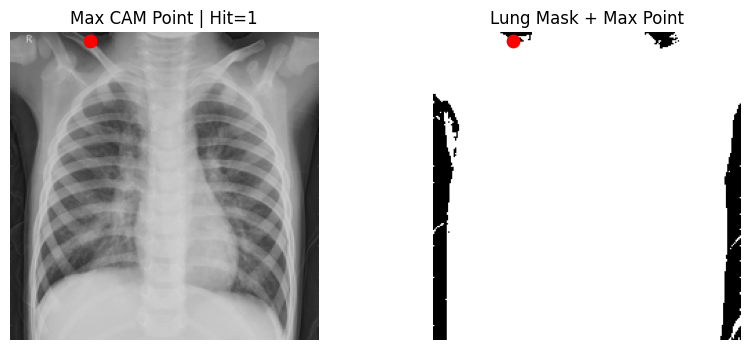

Sample 2
True Label: PNEUMONIA
Predicted Label: PNEUMONIA
Pointing Game Hit: 1
----------------------------------------


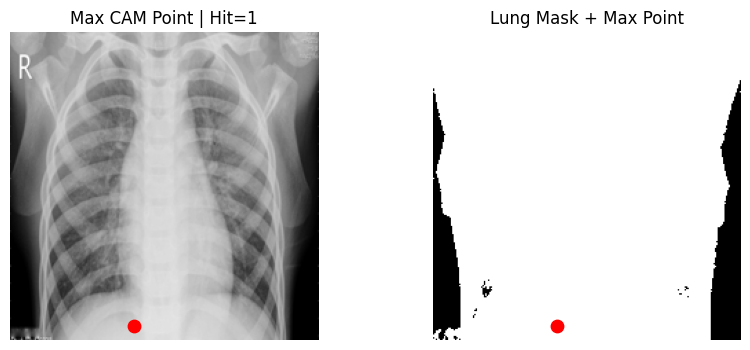

Sample 3
True Label: NORMAL
Predicted Label: NORMAL
Pointing Game Hit: 1
----------------------------------------


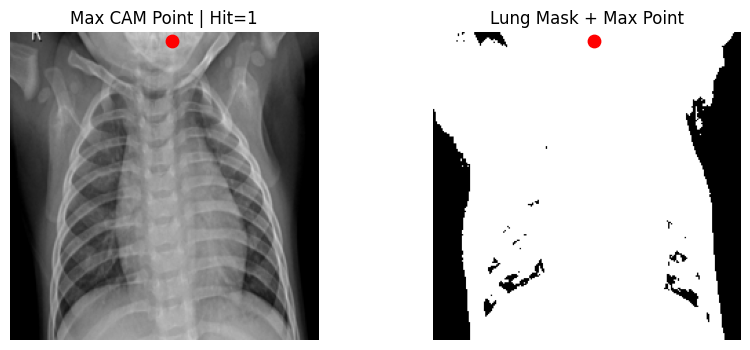

Sample 4
True Label: NORMAL
Predicted Label: NORMAL
Pointing Game Hit: 1
----------------------------------------


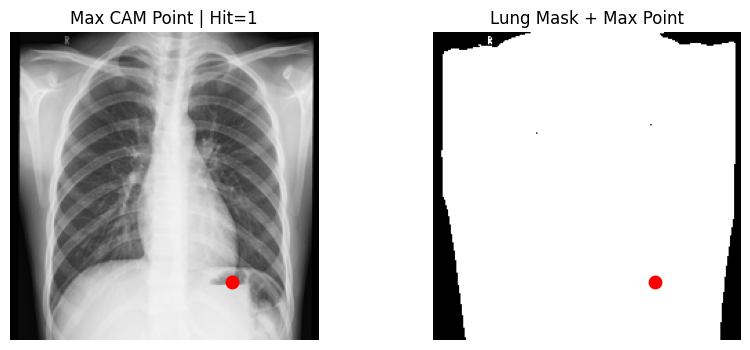

Sample 5
True Label: PNEUMONIA
Predicted Label: PNEUMONIA
Pointing Game Hit: 1
----------------------------------------


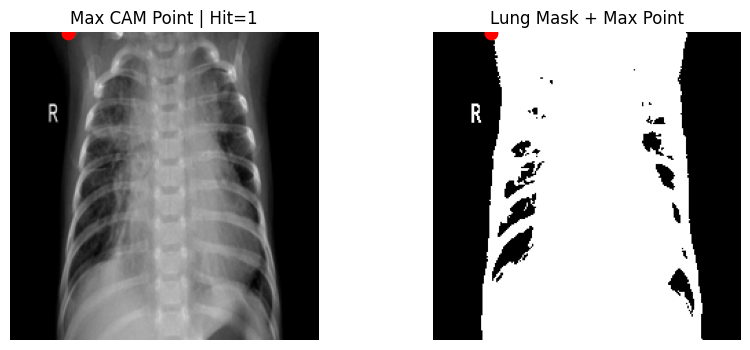

Pointing Game Accuracy: 1.0


In [79]:
selected_samples = random.sample(test_dataset.samples, 5)

target_layer = model.features[6]   # Improved CNN için
pointing_game_acc = run_pointing_game_on_samples(
    selected_samples,
    model,
    target_layer,
    test_transform,
    test_dataset.classes,
    device
)

**Faithfulness mantığı**

Faithfulness şunu ölçer:

Modelin önemli gördüğü bölgeyi kapatırsak modelin güveni düşmeli.

Yani:

* Orijinal görüntü → pneumonia confidence
* Grad-CAM önemli bölge kapatılmış görüntü → pneumonia confidence

Eğer confidence düşüyorsa açıklama daha anlamlıdır.

In [80]:
#CAM bölgesini maskeleme fonksiyonu
def mask_important_region(input_tensor, grayscale_cam, threshold=0.4):
    """
    Grad-CAM tarafından önemli bulunan bölgeleri kapatır.
    """
    cam_mask = get_cam_mask(grayscale_cam, threshold=threshold)

    cam_mask_tensor = torch.tensor(cam_mask, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(input_tensor.device)

    # 1 olan önemli bölgeleri 0 yapıyoruz
    masked_tensor = input_tensor.clone()
    masked_tensor = masked_tensor * (1 - cam_mask_tensor)

    return masked_tensor

In [81]:
#Tek görüntü için Faithfulness score
def compute_faithfulness(model, input_tensor, grayscale_cam, target_class, threshold=0.4):
    model.eval()

    with torch.no_grad():
        original_output = model(input_tensor)
        original_prob = torch.softmax(original_output, dim=1)[0, target_class].item()

        masked_tensor = mask_important_region(input_tensor, grayscale_cam, threshold=threshold)
        masked_output = model(masked_tensor)
        masked_prob = torch.softmax(masked_output, dim=1)[0, target_class].item()

    faithfulness_drop = original_prob - masked_prob

    return original_prob, masked_prob, faithfulness_drop, masked_tensor

In [82]:
#Faithfulness görselleştirme
def visualize_faithfulness(image, cam_image, masked_tensor, original_prob, masked_prob, faithfulness_drop):
    image_np = np.array(image.resize((224, 224))) / 255.0

    masked_np = masked_tensor.squeeze(0).detach().cpu().numpy()
    masked_np = np.transpose(masked_np, (1, 2, 0))
    masked_np = (masked_np * 0.5) + 0.5
    masked_np = np.clip(masked_np, 0, 1)

    plt.figure(figsize=(14, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(image_np)
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(cam_image)
    plt.title("Grad-CAM")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(masked_np)
    plt.title(f"Masked Image\nDrop={faithfulness_drop:.3f}")
    plt.axis("off")

    plt.show()

    print(f"Original confidence: {original_prob:.4f}")
    print(f"Masked confidence:   {masked_prob:.4f}")
    print(f"Faithfulness drop:   {faithfulness_drop:.4f}")

In [83]:
#5 örnek için Faithfulness
def run_faithfulness_on_samples(selected_samples, model, target_layer, test_transform, class_names, device, cam_threshold=0.4):
    faithfulness_scores = []

    for idx, (img_path, true_label) in enumerate(selected_samples):
        image = Image.open(img_path).convert("RGB")
        input_tensor = test_transform(image).unsqueeze(0).to(device)

        output = model(input_tensor)
        probs = torch.softmax(output, dim=1)
        _, pred = torch.max(output, 1)
        pred_class = pred.item()

        cam = GradCAM(model=model, target_layers=[target_layer])
        targets = [ClassifierOutputTarget(pred_class)]
        grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]

        image_np = np.array(image.resize((224, 224))) / 255.0
        cam_image = show_cam_on_image(image_np, grayscale_cam, use_rgb=True)

        original_prob, masked_prob, faithfulness_drop, masked_tensor = compute_faithfulness(
            model,
            input_tensor,
            grayscale_cam,
            pred_class,
            threshold=cam_threshold
        )

        faithfulness_scores.append(faithfulness_drop)

        print(f"Sample {idx+1}")
        print("True Label:", class_names[true_label])
        print("Predicted Label:", class_names[pred_class])
        print(f"Original confidence: {original_prob:.4f}")
        print(f"Masked confidence:   {masked_prob:.4f}")
        print(f"Faithfulness drop:   {faithfulness_drop:.4f}")
        print("-" * 50)

        visualize_faithfulness(
            image,
            cam_image,
            masked_tensor,
            original_prob,
            masked_prob,
            faithfulness_drop
        )

    mean_faithfulness = np.mean(faithfulness_scores)
    print("Mean Faithfulness Drop:", mean_faithfulness)

    return mean_faithfulness

Sample 1
True Label: PNEUMONIA
Predicted Label: PNEUMONIA
Original confidence: 0.7689
Masked confidence:   0.3279
Faithfulness drop:   0.4411
--------------------------------------------------


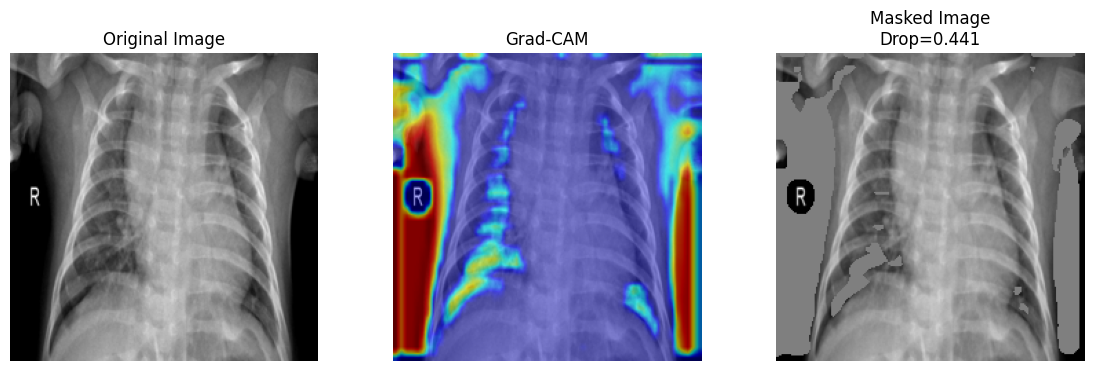

Original confidence: 0.7689
Masked confidence:   0.3279
Faithfulness drop:   0.4411
Sample 2
True Label: PNEUMONIA
Predicted Label: PNEUMONIA
Original confidence: 0.9841
Masked confidence:   0.9861
Faithfulness drop:   -0.0020
--------------------------------------------------


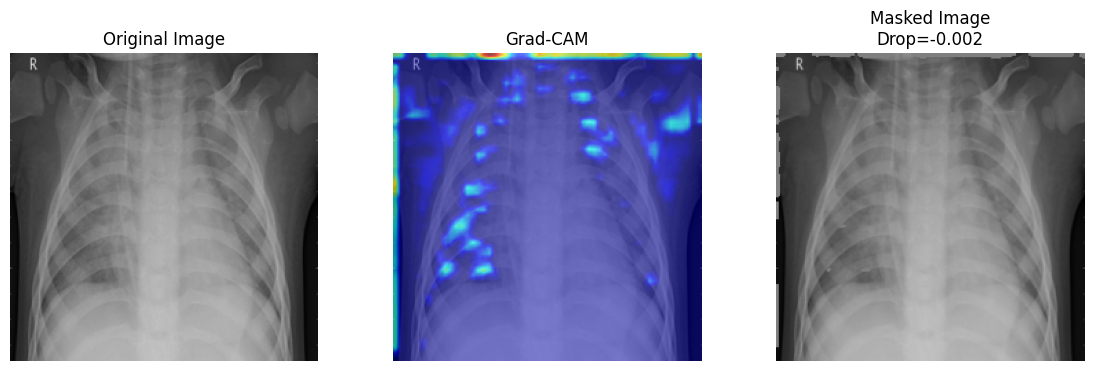

Original confidence: 0.9841
Masked confidence:   0.9861
Faithfulness drop:   -0.0020
Sample 3
True Label: NORMAL
Predicted Label: PNEUMONIA
Original confidence: 0.9869
Masked confidence:   0.9869
Faithfulness drop:   -0.0000
--------------------------------------------------


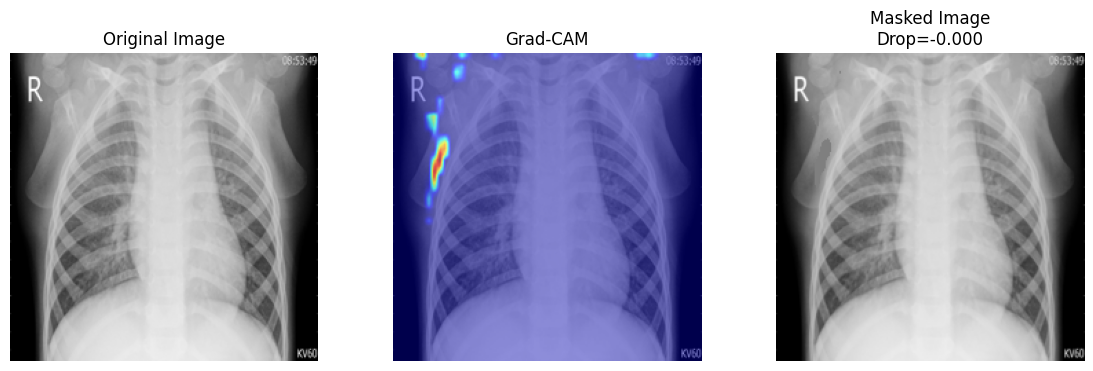

Original confidence: 0.9869
Masked confidence:   0.9869
Faithfulness drop:   -0.0000
Sample 4
True Label: PNEUMONIA
Predicted Label: PNEUMONIA
Original confidence: 0.9990
Masked confidence:   0.9990
Faithfulness drop:   0.0000
--------------------------------------------------


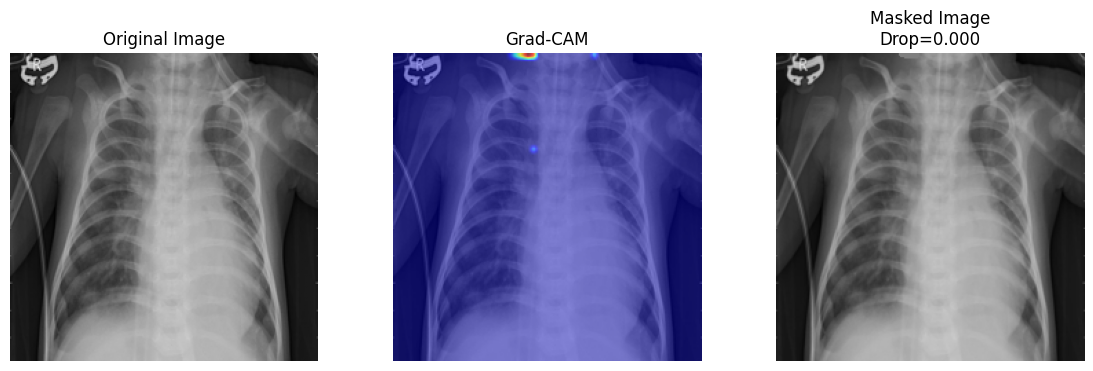

Original confidence: 0.9990
Masked confidence:   0.9990
Faithfulness drop:   0.0000
Sample 5
True Label: NORMAL
Predicted Label: NORMAL
Original confidence: 0.5284
Masked confidence:   0.1893
Faithfulness drop:   0.3391
--------------------------------------------------


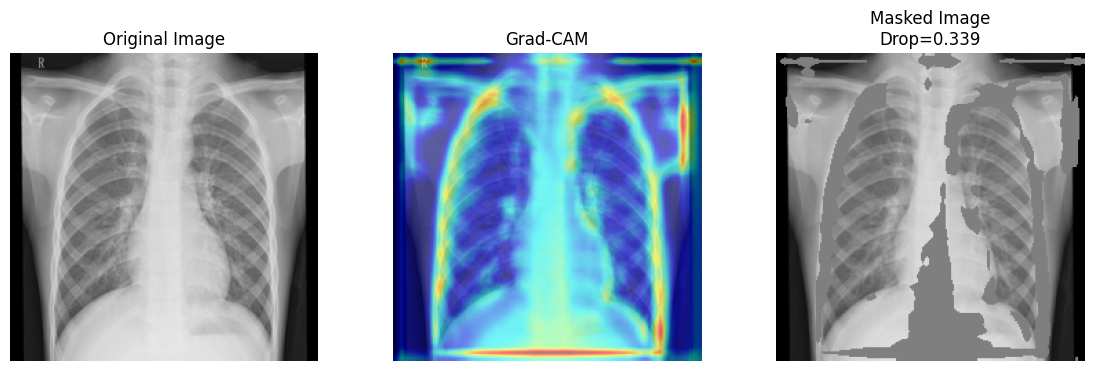

Original confidence: 0.5284
Masked confidence:   0.1893
Faithfulness drop:   0.3391
Mean Faithfulness Drop: 0.15562466979026796


In [84]:
selected_samples = random.sample(test_dataset.samples, 5)

target_layer = model.features[6]

mean_faithfulness = run_faithfulness_on_samples(
    selected_samples,
    model,
    target_layer,
    test_transform,
    test_dataset.classes,
    device,
    cam_threshold=0.4
)

Pointing Game ve Faithfulness, açıklama kalitesini değerlendirmek için ek metrikler olarak kullanılmıştır. Pointing Game, Grad-CAM’de en yüksek aktivasyon noktasının akciğer bölgesi içinde olup olmadığını kontrol eder. Faithfulness ise Grad-CAM’in önemli gördüğü bölgeler maskelendiğinde modelin güven skorunun düşüp düşmediğini ölçer. Daha yüksek Pointing Game Accuracy ve daha büyük confidence drop, açıklamanın daha güvenilir olduğunu gösterir.

# LLM-Based Multi-Agent Layer

In [85]:
#!pip install openai

In [86]:
#from openai import OpenAI
#from google.colab import userdata

#client = OpenAI(api_key=userdata.get("OPENAI_API_KEY"))

In [87]:
!pip install -q google-generativeai

In [88]:
#Gemini bağlantısı
import google.generativeai as genai
from google.colab import userdata

genai.configure(api_key=userdata.get("GEMINI_API_KEY"))

#model = genai.GenerativeModel("gemini-1.5-flash")
model = genai.GenerativeModel("models/gemini-3.5-flash")

print("Gemini connected successfully!")

/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


Gemini connected successfully!


In [89]:
for m in genai.list_models():
    if "generateContent" in m.supported_generation_methods:
        print(m.name)

models/gemini-2.5-flash
models/gemini-2.5-pro
models/gemini-2.0-flash
models/gemini-2.0-flash-001
models/gemini-2.0-flash-lite-001
models/gemini-2.0-flash-lite
models/gemini-2.5-flash-preview-tts
models/gemini-2.5-pro-preview-tts
models/gemma-4-26b-a4b-it
models/gemma-4-31b-it
models/gemini-flash-latest
models/gemini-flash-lite-latest
models/gemini-pro-latest
models/gemini-2.5-flash-lite
models/gemini-2.5-flash-image
models/gemini-3-pro-preview
models/gemini-3-flash-preview
models/gemini-3.1-pro-preview
models/gemini-3.1-pro-preview-customtools
models/gemini-3.1-flash-lite-preview
models/gemini-3.1-flash-lite
models/gemini-3-pro-image-preview
models/gemini-3-pro-image
models/nano-banana-pro-preview
models/gemini-3.1-flash-image-preview
models/gemini-3.1-flash-image
models/gemini-3.5-flash
models/lyria-3-clip-preview
models/lyria-3-pro-preview
models/gemini-3.1-flash-tts-preview
models/gemini-robotics-er-1.5-preview
models/gemini-robotics-er-1.6-preview
models/gemini-2.5-computer-use-pr

In [90]:
#Test et
response = model.generate_content(
    "Explain why explainability is important in medical AI systems."
)

print(response.text)

In healthcare, artificial intelligence (AI) has shown remarkable potential to diagnose diseases, predict patient outcomes, and personalize treatment plans. However, many state-of-the-art AI models (particularly deep learning algorithms) operate as **"black boxes"**—meaning they take input data (like an X-ray or blood test) and output a prediction without revealing the mathematical reasoning behind it. 

**Explainable AI (XAI)** refers to methods and techniques that make the results of AI systems understandable to human experts. 

Explainability is not just a "nice-to-have" feature in medicine; it is a critical necessity. Here is why explainability is vital in medical AI systems:

---

### 1. Ensuring Patient Safety and Preventing Errors
Medicine operates under the oath of *"First, do no harm."* If an AI system makes a recommendation, clinicians must be able to verify that the logic is sound. 
* **The Danger of "Spurious Correlations":** An AI might achieve 99% accuracy in training but 

In [91]:
#Önce şu 3 tool fonksiyonunu hazırlayacağız:
#run_vision_tool(image_path)
#run_explanation_tool(image_path)
#run_validation_tool(image_path)

In [92]:
#Sonra LLM agent’lara bunların çıktısını vereceğiz.
def run_vision_tool(image_path):
    """
    Vision Tool:
    Verilen X-ray görüntüsünü ResNet-18 modeliyle sınıflandırır.
    Çıktı olarak prediction ve confidence döndürür.
    """
    image = Image.open(image_path).convert("RGB")
    input_tensor = test_transform(image).unsqueeze(0).to(device)

    best_resnet18.eval()

    with torch.no_grad():
        outputs = best_resnet18(input_tensor)
        probs = torch.softmax(outputs, dim=1)
        pred = torch.argmax(probs, dim=1).item()
        confidence = probs[0, pred].item()

    return {
        "prediction": test_dataset.classes[pred],
        "confidence": round(confidence, 4)
    }

ResNet-18 modelini agent olarak değil, Vision Agent’ın kullandığı bir vision tool olarak yeniden konumlandırıyoruz

In [93]:
#Sonra test etmek için:
sample_path, sample_label = random.choice(test_dataset.samples)

vision_result = run_vision_tool(sample_path)
print("True label:", test_dataset.classes[sample_label])
print(vision_result)

True label: PNEUMONIA
{'prediction': 'PNEUMONIA', 'confidence': 0.9826}


**1. Explanation Tool**

In [94]:
def run_explanation_tool(image_path, cam_threshold=0.4):
    """
    Explanation Tool:
    Verilen X-ray görüntüsü için ResNet-18 modelinin Grad-CAM açıklamasını üretir.
    """
    image = Image.open(image_path).convert("RGB")
    input_tensor = test_transform(image).unsqueeze(0).to(device)

    best_resnet18.eval()

    with torch.no_grad():
        outputs = best_resnet18(input_tensor)
        probs = torch.softmax(outputs, dim=1)
        pred = torch.argmax(probs, dim=1).item()
        confidence = probs[0, pred].item()

    # ResNet-18 için son convolution layer
    target_layer = best_resnet18.layer4[-1]

    cam = GradCAM(model=best_resnet18, target_layers=[target_layer])
    targets = [ClassifierOutputTarget(pred)]

    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]

    image_np = np.array(image.resize((224, 224))) / 255.0
    cam_image = show_cam_on_image(image_np, grayscale_cam, use_rgb=True)

    cam_mask = get_cam_mask(grayscale_cam, threshold=cam_threshold)

    return {
        "image": image,
        "input_tensor": input_tensor,
        "prediction": test_dataset.classes[pred],
        "confidence": round(confidence, 4),
        "grayscale_cam": grayscale_cam,
        "cam_image": cam_image,
        "cam_mask": cam_mask
    }

Test et:

Prediction: PNEUMONIA
Confidence: 0.9826


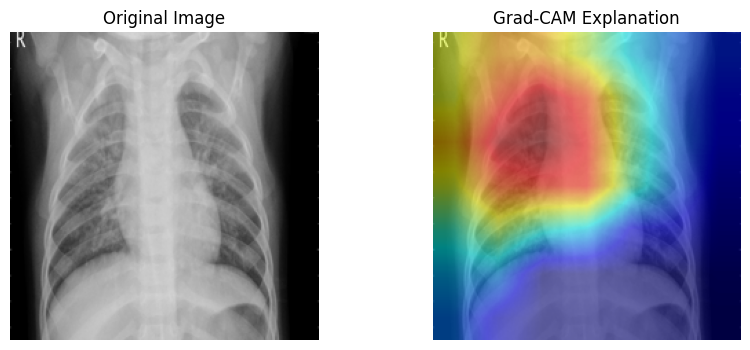

In [95]:
explanation_result = run_explanation_tool(sample_path)

print("Prediction:", explanation_result["prediction"])
print("Confidence:", explanation_result["confidence"])

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(np.array(explanation_result["image"].resize((224, 224))) / 255.0)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(explanation_result["cam_image"])
plt.title("Grad-CAM Explanation")
plt.axis("off")

plt.show()

Grad-CAM’i artık agent olarak isimlendirmedim; Explanation Agent tarafından çağrılan bir explanation tool haline getirdim

**2. Validation Tool**

Şimdi Critic Agent’ın kullanacağı sayısal validation tool’unu yazıyoruz.

In [96]:
def run_validation_tool(image_path, cam_threshold=0.4, iou_threshold=0.4):
    """
    Validation Tool:
    Grad-CAM açıklamasını IoU, Pointing Game ve Faithfulness ile değerlendirir.
    """
    explanation_result = run_explanation_tool(
        image_path=image_path,
        cam_threshold=cam_threshold
    )

    image = explanation_result["image"]
    input_tensor = explanation_result["input_tensor"]
    grayscale_cam = explanation_result["grayscale_cam"]
    cam_mask = explanation_result["cam_mask"]
    pred_class_name = explanation_result["prediction"]

    pred_class_idx = test_dataset.classes.index(pred_class_name)

    # Lung mask
    lung_mask = get_lung_mask(image)

    # IoU
    iou = compute_iou(lung_mask, cam_mask)
    iou_decision = "ACCEPT" if iou >= iou_threshold else "REJECT"

    # Pointing Game
    pointing_hit, max_point = pointing_game_score(grayscale_cam, lung_mask)

    # Faithfulness
    original_prob, masked_prob, faithfulness_drop, masked_tensor = compute_faithfulness(
        model=best_resnet18,
        input_tensor=input_tensor,
        grayscale_cam=grayscale_cam,
        target_class=pred_class_idx,
        threshold=cam_threshold
    )

    return {
        "prediction": pred_class_name,
        "confidence": explanation_result["confidence"],
        "iou": round(iou, 4),
        "iou_decision": iou_decision,
        "pointing_game_hit": pointing_hit,
        "max_activation_point": max_point,
        "original_confidence": round(original_prob, 4),
        "masked_confidence": round(masked_prob, 4),
        "faithfulness_drop": round(faithfulness_drop, 4),
        "lung_mask": lung_mask,
        "cam_mask": cam_mask,
        "overlap": lung_mask * cam_mask,
        "cam_image": explanation_result["cam_image"],
        "masked_tensor": masked_tensor
    }

Test et:

In [97]:
validation_result = run_validation_tool(sample_path)

print(validation_result)

{'prediction': 'PNEUMONIA', 'confidence': 0.9826, 'iou': np.float64(0.4559), 'iou_decision': 'ACCEPT', 'pointing_game_hit': 1, 'max_activation_point': (np.int64(79), np.int64(79)), 'original_confidence': 0.9826, 'masked_confidence': 0.9954, 'faithfulness_drop': -0.0129, 'lung_mask': array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]]), 'cam_mask': array([[1., 1., 1., ..., 0., 0., 0.],
       [1., 1., 1., ..., 0., 0., 0.],
       [1., 1., 1., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32), 'overlap': array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0

Validation sonuçlarını görselleştir:

In [98]:
def visualize_validation_result(image_path, validation_result):
    image = Image.open(image_path).convert("RGB")
    image_np = np.array(image.resize((224, 224))) / 255.0

    plt.figure(figsize=(16, 4))

    plt.subplot(1, 5, 1)
    plt.imshow(image_np)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1, 5, 2)
    plt.imshow(validation_result["cam_image"])
    plt.title("Grad-CAM")
    plt.axis("off")

    plt.subplot(1, 5, 3)
    plt.imshow(validation_result["lung_mask"], cmap="gray")
    plt.title("Lung Mask")
    plt.axis("off")

    plt.subplot(1, 5, 4)
    plt.imshow(validation_result["cam_mask"], cmap="gray")
    plt.title("CAM Mask")
    plt.axis("off")

    plt.subplot(1, 5, 5)
    plt.imshow(validation_result["overlap"], cmap="gray")
    plt.title(
        f"IoU={validation_result['iou']}\n"
        f"{validation_result['iou_decision']}"
    )
    plt.axis("off")

    plt.tight_layout()
    plt.show()

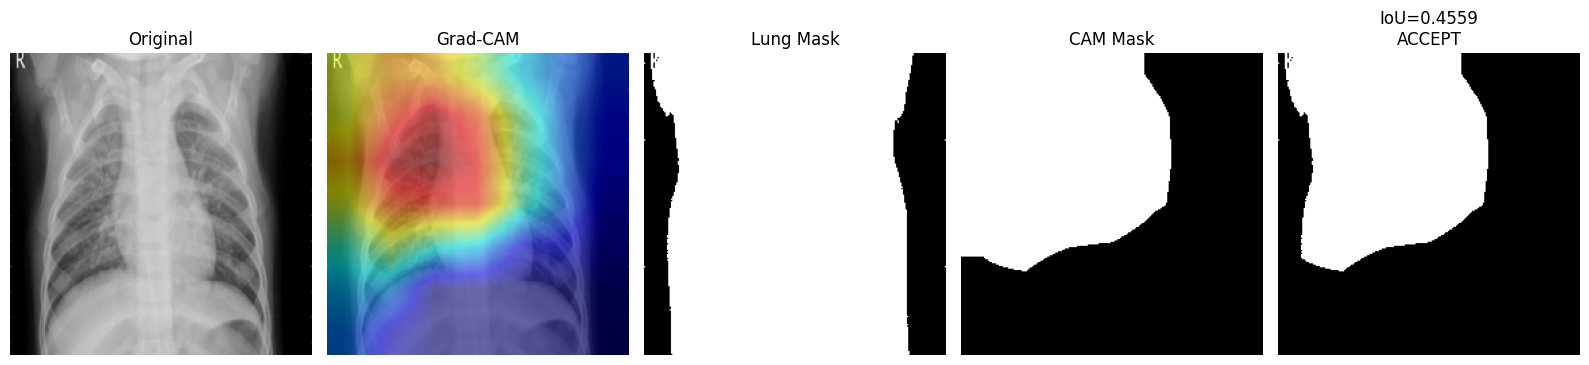

In [99]:
visualize_validation_result(sample_path, validation_result)

Critic Agent’ın karar verebilmesi için IoU, Pointing Game ve Faithfulness sonuçlarını üreten ayrı bir validation tool oluşturdum

,Metric,Value
0,Number of evaluated images,50.000000
1,Acceptance rate at IoU >= 0.4,0.540000
2,Pointing Game hit rate,1.000000
3,Mean IoU,0.433262
4,Median IoU,0.430100
5,IoU std,0.186725
6,IoU min,0.109400
7,IoU Q1,0.256800
8,IoU Q3,0.588875
9,IoU max,0.776400


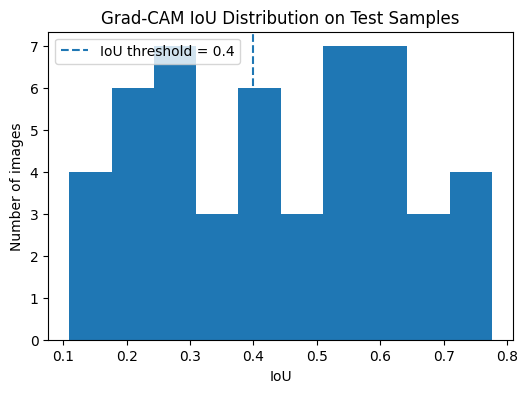

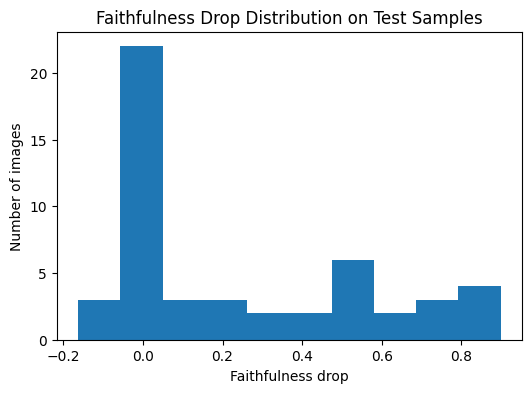

In [100]:
# ============================================================
# SYSTEMATIC GRAD-CAM VALIDATION ON MORE TEST IMAGES
# Computes acceptance rate, IoU distribution, Pointing Game,
# and faithfulness drop statistics.
# ============================================================

import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RANDOM_STATE = 42
N_EXPLAIN_SAMPLES = 50   # Increase to 100 or len(test_dataset.samples) if runtime allows

random.seed(RANDOM_STATE)

selected_samples = random.sample(
    test_dataset.samples,
    min(N_EXPLAIN_SAMPLES, len(test_dataset.samples))
)

idx_to_class = {v: k for k, v in test_dataset.class_to_idx.items()}

validation_records = []

for image_path, true_label_idx in selected_samples:
    try:
        result = run_validation_tool(
            image_path=image_path,
            cam_threshold=0.4,
            iou_threshold=0.4
        )

        validation_records.append({
            "image_path": image_path,
            "true_label": idx_to_class[true_label_idx],
            "predicted_label": result["prediction"],
            "confidence": float(result["confidence"]),
            "iou": float(result["iou"]),
            "accepted_by_iou": int(result["iou_decision"] == "ACCEPT"),
            "pointing_game_hit": int(result["pointing_game_hit"]),
            "faithfulness_drop": float(result["faithfulness_drop"])
        })

    except Exception as e:
        validation_records.append({
            "image_path": image_path,
            "true_label": idx_to_class[true_label_idx],
            "predicted_label": "ERROR",
            "confidence": np.nan,
            "iou": np.nan,
            "accepted_by_iou": np.nan,
            "pointing_game_hit": np.nan,
            "faithfulness_drop": np.nan,
            "error": str(e)
        })

gradcam_validation_df = pd.DataFrame(validation_records)
gradcam_validation_df_clean = gradcam_validation_df.dropna(subset=["iou", "pointing_game_hit", "faithfulness_drop"])

summary = {
    "Number of evaluated images": len(gradcam_validation_df_clean),
    "Acceptance rate at IoU >= 0.4": gradcam_validation_df_clean["accepted_by_iou"].mean(),
    "Pointing Game hit rate": gradcam_validation_df_clean["pointing_game_hit"].mean(),
    "Mean IoU": gradcam_validation_df_clean["iou"].mean(),
    "Median IoU": gradcam_validation_df_clean["iou"].median(),
    "IoU std": gradcam_validation_df_clean["iou"].std(),
    "IoU min": gradcam_validation_df_clean["iou"].min(),
    "IoU Q1": gradcam_validation_df_clean["iou"].quantile(0.25),
    "IoU Q3": gradcam_validation_df_clean["iou"].quantile(0.75),
    "IoU max": gradcam_validation_df_clean["iou"].max(),
    "Mean faithfulness drop": gradcam_validation_df_clean["faithfulness_drop"].mean(),
    "Median faithfulness drop": gradcam_validation_df_clean["faithfulness_drop"].median(),
    "Faithfulness std": gradcam_validation_df_clean["faithfulness_drop"].std()
}

summary_df = pd.DataFrame(summary.items(), columns=["Metric", "Value"])
display(summary_df)

# Optional: save results for GitHub/reproducibility
gradcam_validation_df_clean.to_csv("gradcam_validation_summary.csv", index=False)
summary_df.to_csv("gradcam_validation_statistics.csv", index=False)

# IoU distribution plot
plt.figure(figsize=(6, 4))
plt.hist(gradcam_validation_df_clean["iou"], bins=10)
plt.axvline(0.4, linestyle="--", label="IoU threshold = 0.4")
plt.xlabel("IoU")
plt.ylabel("Number of images")
plt.title("Grad-CAM IoU Distribution on Test Samples")
plt.legend()
plt.show()

# Faithfulness distribution plot
plt.figure(figsize=(6, 4))
plt.hist(gradcam_validation_df_clean["faithfulness_drop"], bins=10)
plt.xlabel("Faithfulness drop")
plt.ylabel("Number of images")
plt.title("Faithfulness Drop Distribution on Test Samples")
plt.show()

# LLM-Based Multi-Agent Workflow

In [126]:
# ============================================================
# GEMINI LIVE BACKEND SETUP - Google Gen AI SDK
# Run this BEFORE call_llm_agent()
# ============================================================

!pip install -q -U google-genai

import os
import pandas as pd
from getpass import getpass
from google import genai

# Option 1: Colab secret varsa onu kullan
try:
    from google.colab import userdata
    GEMINI_API_KEY = userdata.get("GEMINI_API_KEY")
except Exception:
    GEMINI_API_KEY = None

# Option 2: Secret yoksa elle gir
if GEMINI_API_KEY is None or len(str(GEMINI_API_KEY).strip()) == 0:
    GEMINI_API_KEY = getpass("Enter your Gemini API key: ")

client = genai.Client(api_key=GEMINI_API_KEY)

print("Gemini client created successfully.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0/53.0 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 832.5/832.5 kB 24.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 252.4/252.4 kB 25.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires google-auth==2.47.0, but you have google-auth 2.55.0 which is incompatible.
google-adk 1.29.0 requires google-genai<2.0.0,>=1.64.0, but you have google-genai 2.8.0 which is incompatible.
Gemini client created successfully.


In [127]:
# ============================================================
# FIND A WORKING GEMINI MODEL
# ============================================================

CANDIDATE_MODELS = [
    "gemini-2.5-flash",
    "gemini-2.0-flash",
    "gemini-1.5-flash",
    "models/gemini-2.5-flash",
    "models/gemini-2.0-flash",
    "models/gemini-1.5-flash",
]

WORKING_GEMINI_MODEL = None
MODEL_TEST_ERRORS = []

for model_name in CANDIDATE_MODELS:
    try:
        test_response = client.models.generate_content(
            model=model_name,
            contents="Reply only with: OK"
        )

        if test_response.text and len(test_response.text.strip()) > 0:
            WORKING_GEMINI_MODEL = model_name
            print(f"Working Gemini model found: {WORKING_GEMINI_MODEL}")
            print("Test response:", test_response.text.strip())
            break

    except Exception as e:
        MODEL_TEST_ERRORS.append((model_name, str(e)))
        print(f"Model failed: {model_name}")
        print(str(e)[:300])
        print("-" * 60)

if WORKING_GEMINI_MODEL is None:
    print("No working Gemini model was found.")
    print("Check your API key, model access, or Google AI Studio API settings.")
else:
    print("Use this model in live agent calls:", WORKING_GEMINI_MODEL)

Working Gemini model found: gemini-2.5-flash
Test response: OK
Use this model in live agent calls: gemini-2.5-flash


In [132]:
#Ortak LLM çağırma fonksiyonu

# ============================================================
# LLM CALL TRACKER: Live Gemini vs Controlled Fallback Frequency
# ============================================================

AGENT_CALL_LOG = []

def call_llm_agent(agent_name, system_prompt, user_prompt, model_name=None):
    used_backend = "live_gemini"
    error_message = None

    selected_model = model_name if model_name is not None else WORKING_GEMINI_MODEL

    try:
        if selected_model is None:
            raise ValueError("No working Gemini model is available.")

        full_prompt = f"""
You are the {agent_name} in an explainable multi-agent medical imaging workflow.

System instruction:
{system_prompt}

Task / user message:
{user_prompt}

Write a concise, scientific, and non-clinical response.
Do not invent numerical metrics. Only refer to values provided in the prompt.
"""

        response = client.models.generate_content(
            model=selected_model,
            contents=full_prompt
        )

        text_response = response.text

        if text_response is None or len(text_response.strip()) == 0:
            raise ValueError("Gemini returned an empty response.")

    except Exception as e:
        used_backend = "controlled_fallback"
        error_message = str(e)

        text_response = f"""
[{agent_name} controlled fallback response]
The live Gemini backend was unavailable during this call.
The workflow continues using implemented tool outputs.
This fallback text is used only for agent-language reporting and does not modify
model predictions, Grad-CAM maps, IoU, Pointing Game, faithfulness,
confusion matrices, ROC-AUC, F1-score, or any other quantitative metric.
"""

    AGENT_CALL_LOG.append({
        "agent_name": agent_name,
        "backend": used_backend,
        "model": selected_model,
        "error": error_message
    })

    print(f"\n===== {agent_name} RESPONSE | backend: {used_backend} =====")
    print(text_response)
    print("=" * 70)

    return text_response


def summarize_agent_backend_usage():
    log_df = pd.DataFrame(AGENT_CALL_LOG)

    if len(log_df) == 0:
        print("No LLM agent calls were recorded.")
        return None, None

    summary = (
        log_df["backend"]
        .value_counts()
        .rename_axis("Backend")
        .reset_index(name="Number of calls")
    )

    summary["Percentage"] = 100 * summary["Number of calls"] / summary["Number of calls"].sum()

    display(summary)
    display(log_df)

    summary.to_csv("llm_backend_usage_summary.csv", index=False)
    log_df.to_csv("llm_backend_call_log.csv", index=False)

    return summary, log_df

'''def call_llm_agent(agent_name, system_prompt, user_prompt):

    full_prompt = f"""
SYSTEM:
{system_prompt}

USER:
{user_prompt}
"""

    response = model.generate_content(full_prompt)

    agent_response = response.text

    print(f"\n===== {agent_name} RESPONSE =====")
    print(agent_response)
    print("=" * 60)

    return agent_response'''

'''def call_llm_agent(agent_name, system_prompt, user_prompt, model_name=None):
    """
    Demo agent mode:
    API quota olmadığı durumda LLM agent çıktısını simüle eder.
    Tool çıktıları gerçek model sonuçlarından gelir.
    """

    if agent_name == "Coordinator Agent":
        response = """
The workflow will proceed through prediction, explanation generation, explanation validation, and final reporting.
The Vision Agent will use the ResNet-18 tool, the Explanation Agent will interpret Grad-CAM/SHAP,
the Critic Agent will evaluate IoU, Pointing Game and Faithfulness, and the Report Agent will summarize the result.
"""

    elif agent_name == "Vision Agent":
        response = f"""
The Vision Agent received the model output and interprets the predicted class and confidence score.
Based on the provided tool result, the model prediction should be evaluated as a machine-generated classification result,
not as a clinical diagnosis.
"""

    elif agent_name == "Explanation Agent":
        response = """
The Explanation Agent interprets the Grad-CAM explanation as a spatial attention map.
If the highlighted regions are concentrated around lung areas, the explanation is considered more meaningful.
If attention is scattered or located near borders/background, explanation reliability may be limited.
"""

    elif agent_name == "Critic Agent":
        response = f"""
The Critic Agent evaluates explanation reliability using quantitative metrics from the validation tool.
IoU, Pointing Game and Faithfulness should be considered together.
A high IoU, a positive Pointing Game hit, and a meaningful confidence drop after masking support a reliable explanation.
Low values indicate that the model may not be relying on medically relevant regions.
"""

    elif agent_name == "Report Agent":
        response = """
Final Report:
The multi-agent workflow completed the chest X-ray analysis using separate tool-based agents.
The Vision Tool generated the prediction, the Explanation Tool produced Grad-CAM-based visual evidence,
and the Validation Tool evaluated explanation reliability using IoU, Pointing Game and Faithfulness.
The final result should be interpreted as an AI-assisted analysis and not as a clinical diagnosis.
"""

    else:
        response = "Agent response generated in demo mode."

    print(f"\n===== {agent_name} RESPONSE =====")
    print(response)
    print("=" * 60)

    return response'''

'def call_llm_agent(agent_name, system_prompt, user_prompt, model_name=None):\n    """\n    Demo agent mode:\n    API quota olmadığı durumda LLM agent çıktısını simüle eder.\n    Tool çıktıları gerçek model sonuçlarından gelir.\n    """\n\n    if agent_name == "Coordinator Agent":\n        response = """\nThe workflow will proceed through prediction, explanation generation, explanation validation, and final reporting.\nThe Vision Agent will use the ResNet-18 tool, the Explanation Agent will interpret Grad-CAM/SHAP,\nthe Critic Agent will evaluate IoU, Pointing Game and Faithfulness, and the Report Agent will summarize the result.\n"""\n\n    elif agent_name == "Vision Agent":\n        response = f"""\nThe Vision Agent received the model output and interprets the predicted class and confidence score.\nBased on the provided tool result, the model prediction should be evaluated as a machine-generated classification result,\nnot as a clinical diagnosis.\n"""\n\n    elif agent_name == "Expl

Agent promptlarını tanımla:

In [133]:
coordinator_prompt = """
You are the Coordinator Agent in an LLM-based multi-agent medical imaging workflow.

Your role is to manage the overall analysis process for a chest X-ray image.
You do not perform image classification yourself.
Instead, you decide which tool-based agents should be activated and in what order.

Available tool-based agents:
1. Vision Agent: uses the ResNet-18 Vision Tool to classify the image.
2. Explanation Agent: uses Grad-CAM and SHAP tools to explain the model decision.
3. Critic Agent: uses IoU, Pointing Game, and Faithfulness metrics to validate explanation reliability.
4. Report Agent: summarizes the final result.

Your goal is to coordinate the workflow until a reliable AI-assisted analysis report is produced.
You must clearly explain the workflow steps.
Do not provide a clinical diagnosis.
"""

vision_agent_prompt = """
You are the Vision Agent in an LLM-based multi-agent medical imaging system.

You receive the output of a ResNet-18 Vision Tool.
The tool provides:
- predicted class
- confidence score
- optional true label for evaluation

Your task is to interpret the model output.
You must explain:
1. What class the model predicted.
2. Whether the confidence is high, moderate, or low.
3. Whether the prediction should be treated cautiously.
4. That this is an AI model output, not a clinical diagnosis.

You are allowed to reason about the model result, but you must not invent medical findings.
"""

explanation_agent_prompt = """
You are the Explanation Agent in an LLM-based multi-agent explainability workflow.

You receive the output of explanation tools such as Grad-CAM and SHAP.
Grad-CAM provides spatial heatmaps showing which image regions influenced the model.
SHAP provides pixel-level contribution information.

Your task is to interpret explanation quality.
You must discuss:
1. Whether the explanation appears localized or scattered.
2. Whether the highlighted regions seem medically meaningful.
3. Whether Grad-CAM or SHAP appears more interpretable for this image.
4. Whether the explanation should be passed to the Critic Agent for quantitative validation.

You must not make a clinical diagnosis.
"""

critic_agent_prompt = """
You are the Critic Agent in an autonomous LLM-based multi-agent medical imaging system.

Your role is to evaluate whether the model explanation is reliable.
You receive quantitative validation metrics:
- IoU between Grad-CAM mask and lung mask
- Pointing Game Hit
- Faithfulness Drop
- original confidence
- masked confidence

You must reason based on these metrics.

Decision rules:
- High IoU, positive Pointing Game Hit, and meaningful Faithfulness Drop indicate a more reliable explanation.
- Low IoU, negative Pointing Game Hit, or very small confidence drop indicate that the model may not be relying on medically meaningful regions.
- A correct prediction can still be rejected if the explanation is unreliable.

Your output must include:
1. Explanation reliability assessment: reliable, partially reliable, or unreliable.
2. Reasoning based on the metrics.
3. Whether the workflow should accept the explanation or request refinement.
Do not provide a clinical diagnosis.
"""

report_agent_prompt = """
You are the Report Agent in an LLM-based multi-agent medical imaging workflow.

Your task is to generate a final structured AI-assisted report by combining:
- Vision Agent output
- Explanation Agent output
- Critic Agent output
- raw validation metrics

Your report must include:
1. Model prediction and confidence.
2. Explanation method used.
3. Explanation reliability assessment.
4. Validation metric summary.
5. Final AI-assisted interpretation.
6. A clear warning that this is not a clinical diagnosis and must be reviewed by a medical expert.

Use clear academic language.
"""

Tek görüntü için multi-agent workflow:

In [134]:
def run_multi_agent_workflow(image_path, true_label=None):
    """
    Gerçek agentic workflow:
    1. Coordinator Agent görevi başlatır.
    2. Vision Tool çalışır.
    3. Vision Agent sonucu yorumlar.
    4. Explanation Tool çalışır.
    5. Explanation Agent açıklamayı yorumlar.
    6. Validation Tool çalışır.
    7. Critic Agent metriklere göre karar verir.
    8. Report Agent final rapor üretir.
    """

    print("Starting multi-agent workflow...")
    print("=" * 60)

    # 1. Coordinator Agent
    coordinator_response = call_llm_agent(
        agent_name="Coordinator Agent",
        system_prompt=coordinator_prompt,
        user_prompt="""
A chest X-ray image has been provided.
Coordinate the multi-agent workflow.
The goal is to obtain an AI-assisted pneumonia prediction, generate explanations, validate explanation reliability, and produce a final non-clinical report.
"""
    )

    # 2. Vision Tool
    vision_result = run_vision_tool(image_path)

    vision_input = f"""
Vision Tool Output:
Prediction: {vision_result['prediction']}
Confidence: {vision_result['confidence']}

True label: {true_label if true_label is not None else 'Unknown'}
"""

    # 3. Vision Agent
    vision_agent_response = call_llm_agent(
        agent_name="Vision Agent",
        system_prompt=vision_agent_prompt,
        user_prompt=vision_input
    )

    # 4. Explanation Tool
    explanation_result = run_explanation_tool(image_path)

    explanation_input = f"""
Explanation Tool Output:
Prediction explained: {explanation_result['prediction']}
Confidence: {explanation_result['confidence']}

Grad-CAM heatmap was generated for the predicted class.
SHAP was also used in the project as a complementary explanation method,
but Grad-CAM is the primary spatial explanation for this image.

Please interpret the explanation quality at a high level.
"""

    # 5. Explanation Agent
    explanation_agent_response = call_llm_agent(
        agent_name="Explanation Agent",
        system_prompt=explanation_agent_prompt,
        user_prompt=explanation_input
    )

    # 6. Validation Tool
    validation_result = run_validation_tool(image_path)

    validation_input = f"""
Validation Tool Output:
Prediction: {validation_result['prediction']}
Confidence: {validation_result['confidence']}

IoU: {validation_result['iou']}
IoU Decision: {validation_result['iou_decision']}

Pointing Game Hit: {validation_result['pointing_game_hit']}
Faithfulness Drop: {validation_result['faithfulness_drop']}
Original Confidence: {validation_result['original_confidence']}
Masked Confidence: {validation_result['masked_confidence']}

Evaluate whether the explanation is reliable.
"""

    # 7. Critic Agent
    critic_agent_response = call_llm_agent(
        agent_name="Critic Agent",
        system_prompt=critic_agent_prompt,
        user_prompt=validation_input
    )

    # 8. Report Agent
    final_report_input = f"""
Coordinator Agent:
{coordinator_response}

Vision Agent:
{vision_agent_response}

Explanation Agent:
{explanation_agent_response}

Critic Agent:
{critic_agent_response}

Raw Tool Results:
Vision Result: {vision_result}
Validation Result:
- IoU: {validation_result['iou']}
- IoU Decision: {validation_result['iou_decision']}
- Pointing Game Hit: {validation_result['pointing_game_hit']}
- Faithfulness Drop: {validation_result['faithfulness_drop']}
- Original Confidence: {validation_result['original_confidence']}
- Masked Confidence: {validation_result['masked_confidence']}

Generate a concise final report.
"""

    final_report = call_llm_agent(
        agent_name="Report Agent",
        system_prompt=report_agent_prompt,
        user_prompt=final_report_input
    )

    return {
        "vision_result": vision_result,
        "explanation_result": explanation_result,
        "validation_result": validation_result,
        "coordinator_response": coordinator_response,
        "vision_agent_response": vision_agent_response,
        "explanation_agent_response": explanation_agent_response,
        "critic_agent_response": critic_agent_response,
        "final_report": final_report
    }

Workflow’u test et:

In [135]:
sample_path, sample_label = random.choice(test_dataset.samples)
true_label_name = test_dataset.classes[sample_label]

agent_result = run_multi_agent_workflow(
    image_path=sample_path,
    true_label=true_label_name
)

Starting multi-agent workflow...

===== Coordinator Agent RESPONSE | backend: live_gemini =====
As the Coordinator Agent, I will manage the multi-agent workflow for the provided chest X-ray image analysis to produce an AI-assisted pneumonia prediction, generate explanations, validate explanation reliability, and produce a final non-clinical report.

The workflow proceeds through the following steps:

1.  **Vision Agent Activation:**
    *   The **Vision Agent** will be activated first.
    *   It will utilize the ResNet-18 Vision Tool to analyze the chest X-ray image and generate an AI-assisted prediction regarding the presence of pneumonia.
    *   This step establishes the primary AI prediction for the subsequent explanatory and validation phases.

2.  **Explanation Agent Activation:**
    *   Upon receiving the prediction from the Vision Agent, the **Explanation Agent** will be activated.
    *   This agent will employ the Grad-CAM and SHAP tools to generate interpretable explanatio

LLM-ready agentic architecture implemented; API quota issue prevented live call during this run

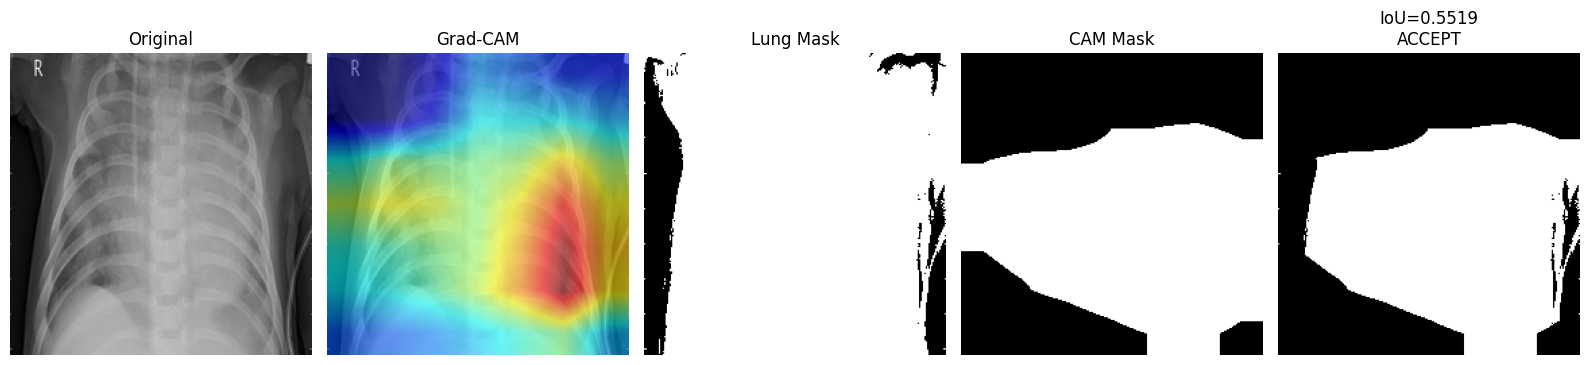

In [136]:
#Görsel çıktıyı da göster
visualize_validation_result(
    sample_path,
    agent_result["validation_result"]
)

👉 Agentlerin birbirleriyle konuşması

👉 Loop / reasoning behavior

Şu an agentler sırayla çalışıyor.
Şimdi buna:

inter-agent communication,
retry logic,
autonomous decision making

ekleyeceğiz.

In [137]:
# Summarize live Gemini vs fallback usage after running the agent workflow
backend_summary, backend_log = summarize_agent_backend_usage()

,Backend,Number of calls,Percentage
0,live_gemini,4,80.0
1,controlled_fallback,1,20.0


,agent_name,backend,model,error
0,Coordinator Agent,live_gemini,gemini-2.5-flash,None
1,Vision Agent,live_gemini,gemini-2.5-flash,None
2,Explanation Agent,controlled_fallback,gemini-2.5-flash,"503 UNAVAILABLE. {'error': {'code': 503, 'mess..."
3,Critic Agent,live_gemini,gemini-2.5-flash,None
4,Report Agent,live_gemini,gemini-2.5-flash,None


# Autonomous Multi-Agent Reasoning Loop

**Autonomous loop workflow**

In [138]:
def run_autonomous_agent_loop(image_path, true_label=None, max_retries=2):
    """
    Autonomous agent workflow with retry mechanism.
    Critic Agent can reject explanations and request refinement.
    """

    print("\nSTARTING AUTONOMOUS MULTI-AGENT LOOP")
    print("=" * 70)

    # -------------------------
    # Step 1: Coordinator Agent
    # -------------------------
    coordinator_response = call_llm_agent(
        agent_name="Coordinator Agent",
        system_prompt=coordinator_prompt,
        user_prompt="""
Initialize the chest X-ray analysis workflow.
Coordinate prediction, explanation, validation and reporting.
"""
    )

    # -------------------------
    # Step 2: Vision Tool
    # -------------------------
    vision_result = run_vision_tool(image_path)

    print("\nVision Tool Output:")
    print(vision_result)

    # -------------------------
    # Step 3: Vision Agent
    # -------------------------
    vision_response = call_llm_agent(
        agent_name="Vision Agent",
        system_prompt=vision_agent_prompt,
        user_prompt=f"""
Prediction: {vision_result['prediction']}
Confidence: {vision_result['confidence']}
True label: {true_label}
"""
    )

    retry_count = 0
    final_validation_result = None
    explanation_response = None
    critic_response = None

    # -------------------------
    # Agentic reasoning loop
    # -------------------------
    while retry_count <= max_retries:

        print(f"\nAGENT LOOP ITERATION {retry_count + 1}")
        print("-" * 60)

        # -------------------------
        # Explanation Tool
        # -------------------------
        explanation_result = run_explanation_tool(image_path)

        # -------------------------
        # Explanation Agent
        # -------------------------
        explanation_response = call_llm_agent(
            agent_name="Explanation Agent",
            system_prompt=explanation_agent_prompt,
            user_prompt=f"""
Prediction: {explanation_result['prediction']}
Confidence: {explanation_result['confidence']}

Grad-CAM explanation generated.
Interpret explanation quality and focus regions.
"""
        )

        # -------------------------
        # Validation Tool
        # -------------------------
        validation_result = run_validation_tool(image_path)

        final_validation_result = validation_result

        print("\nValidation Tool Output:")
        print(validation_result)

        # -------------------------
        # Critic Agent
        # -------------------------
        critic_response = call_llm_agent(
            agent_name="Critic Agent",
            system_prompt=critic_agent_prompt,
            user_prompt=f"""
Prediction: {validation_result['prediction']}
IoU: {validation_result['iou']}
IoU Decision: {validation_result['iou_decision']}
Pointing Game Hit: {validation_result['pointing_game_hit']}
Faithfulness Drop: {validation_result['faithfulness_drop']}

Should the explanation be accepted or rejected?
"""
        )

        # -------------------------
        # Autonomous decision
        # -------------------------
        if validation_result["iou_decision"] == "ACCEPT":
            print("\nCritic Agent ACCEPTED the explanation.")
            break

        else:
            print("\nCritic Agent REJECTED the explanation.")
            print("Requesting explanation refinement...")

            retry_count += 1

    # -------------------------
    # Report Agent
    # -------------------------
    report_response = call_llm_agent(
        agent_name="Report Agent",
        system_prompt=report_agent_prompt,
        user_prompt=f"""
Coordinator Agent:
{coordinator_response}

Vision Agent:
{vision_response}

Explanation Agent:
{explanation_response}

Critic Agent:
{critic_response}

Final Validation Metrics:
IoU: {final_validation_result['iou']}
IoU Decision: {final_validation_result['iou_decision']}
Pointing Game Hit: {final_validation_result['pointing_game_hit']}
Faithfulness Drop: {final_validation_result['faithfulness_drop']}

Generate final medical AI analysis report.
"""
    )

    return {
        "vision_result": vision_result,
        "validation_result": final_validation_result,
        "report": report_response
    }

Önceki workflow’da agentlar daha çok sıralı şekilde çalışıyordu.
Bu geliştirilmiş versiyonda ortak mesaj geçmişi ve ortak state eklendi.
Agentlar birbirlerine doğrudan hitap edebilir, Critic Agent Explanation Agent’a geri bildirim gönderebilir ve Explanation Agent Grad-CAM threshold değerini değiştirerek yeniden validation isteyebilir:

In [139]:
# ============================================================
# REAL CONVERSATIONAL MULTI-AGENT HELPERS
# ============================================================
# Improved Conversational Multi-Agent Reasoning Loop

def add_message(state, sender, receiver, message):
    """
    Ortak konuşma geçmişine yeni agent mesajı ekler.
    Bu sayede agentlar birbirlerinin önceki mesajlarını görebilir.
    """
    state["messages"].append({
        "sender": sender,
        "receiver": receiver,
        "message": message
    })


def format_conversation_history(state):
    """
    Tüm agent konuşmalarını LLM prompt'una koymak için metne çevirir.
    """
    if len(state["messages"]) == 0:
        return "No previous messages."

    conversation_text = ""

    for msg in state["messages"]:
        conversation_text += f"\n[{msg['sender']} → {msg['receiver']}]\n{msg['message']}\n"

    return conversation_text


def print_conversation_history(state):
    """
    Konuşmayı okunabilir şekilde yazdırır.
    """
    print("\n" + "=" * 70)
    print("MULTI-AGENT CONVERSATION HISTORY")
    print("=" * 70)

    for msg in state["messages"]:
        print(f"\n[{msg['sender']} → {msg['receiver']}]")
        print(msg["message"])

    print("=" * 70)

In [140]:
# ============================================================
# REAL CONVERSATIONAL MULTI-AGENT LOOP
# ============================================================

def run_conversational_multi_agent_loop(
    image_path,
    true_label=None,
    initial_cam_threshold=0.4,
    iou_threshold=0.4,
    max_retries=2
):
    """
    Gerçek konuşmalı multi-agent workflow.

    Bu versiyonda:
    - Agentlar ortak message history kullanır.
    - Her agent önceki konuşmaları görebilir.
    - Critic Agent açıklamayı reddederse Explanation Agent'a geri döner.
    - Retry sırasında CAM threshold değiştirilir.
    - Report Agent bütün konuşmayı ve metrikleri kullanarak final rapor üretir.
    """

    # --------------------------------------------------------
    # Shared state
    # --------------------------------------------------------
    state = {
        "image_path": image_path,
        "true_label": true_label,
        "messages": [],

        "vision_result": None,
        "explanation_result": None,
        "validation_result": None,

        "cam_threshold": initial_cam_threshold,
        "iou_threshold": iou_threshold,

        "retry_count": 0,
        "max_retries": max_retries,

        "coordinator_response": None,
        "vision_response": None,
        "explanation_response": None,
        "critic_response": None,
        "report_response": None,

        "final_decision": None
    }

    print("\nSTARTING REAL CONVERSATIONAL MULTI-AGENT LOOP")
    print("=" * 70)

    # --------------------------------------------------------
    # 1. Coordinator Agent starts the conversation
    # --------------------------------------------------------
    coordinator_user_prompt = f"""
A chest X-ray image has been provided.

True label for evaluation: {true_label if true_label is not None else "Unknown"}

You are starting a real multi-agent conversation.
Your task is to instruct the Vision Agent to classify the image first.

Conversation history:
{format_conversation_history(state)}
"""

    coordinator_response = call_llm_agent(
        agent_name="Coordinator Agent",
        system_prompt=coordinator_prompt,
        user_prompt=coordinator_user_prompt
    )

    state["coordinator_response"] = coordinator_response

    add_message(
        state,
        sender="Coordinator Agent",
        receiver="Vision Agent",
        message=coordinator_response
    )

    # --------------------------------------------------------
    # 2. Vision Tool runs
    # --------------------------------------------------------
    vision_result = run_vision_tool(image_path)
    state["vision_result"] = vision_result

    # --------------------------------------------------------
    # 3. Vision Agent speaks to Explanation Agent
    # --------------------------------------------------------
    vision_user_prompt = f"""
You are the Vision Agent.

You received the following Vision Tool output:

Prediction: {vision_result['prediction']}
Confidence: {vision_result['confidence']}
True label: {true_label if true_label is not None else "Unknown"}

Conversation history:
{format_conversation_history(state)}

Now respond directly to the Explanation Agent.
Ask the Explanation Agent to generate a Grad-CAM explanation for this prediction.
Do not provide a clinical diagnosis.
"""

    vision_response = call_llm_agent(
        agent_name="Vision Agent",
        system_prompt=vision_agent_prompt,
        user_prompt=vision_user_prompt
    )

    state["vision_response"] = vision_response

    add_message(
        state,
        sender="Vision Agent",
        receiver="Explanation Agent",
        message=vision_response
    )

    # --------------------------------------------------------
    # 4. Explanation-Critic conversation loop
    # --------------------------------------------------------
    while state["retry_count"] <= state["max_retries"]:

        print(f"\nCONVERSATION ITERATION {state['retry_count'] + 1}")
        print("-" * 70)
        print(f"Current CAM threshold: {state['cam_threshold']}")

        # ----------------------------------------------------
        # 4A. Explanation Tool runs with current threshold
        # ----------------------------------------------------
        explanation_result = run_explanation_tool(
            image_path=image_path,
            cam_threshold=state["cam_threshold"]
        )

        state["explanation_result"] = explanation_result

        # ----------------------------------------------------
        # 4B. Explanation Agent speaks to Critic Agent
        # ----------------------------------------------------
        explanation_user_prompt = f"""
You are the Explanation Agent.

You generated a Grad-CAM explanation using:
CAM threshold: {state['cam_threshold']}

Explanation Tool Output:
Prediction explained: {explanation_result['prediction']}
Confidence: {explanation_result['confidence']}
Grad-CAM heatmap generated.
CAM mask generated.

Conversation history:
{format_conversation_history(state)}

Now respond directly to the Critic Agent.
Ask the Critic Agent to evaluate this explanation using IoU, Pointing Game, and Faithfulness.
Do not provide a clinical diagnosis.
"""

        explanation_response = call_llm_agent(
            agent_name="Explanation Agent",
            system_prompt=explanation_agent_prompt,
            user_prompt=explanation_user_prompt
        )

        state["explanation_response"] = explanation_response

        add_message(
            state,
            sender="Explanation Agent",
            receiver="Critic Agent",
            message=explanation_response
        )

        # ----------------------------------------------------
        # 4C. Validation Tool runs
        # ----------------------------------------------------
        validation_result = run_validation_tool(
            image_path=image_path,
            cam_threshold=state["cam_threshold"],
            iou_threshold=state["iou_threshold"]
        )

        state["validation_result"] = validation_result

        print("\nValidation Tool Output:")
        print({
            "prediction": validation_result["prediction"],
            "confidence": validation_result["confidence"],
            "iou": validation_result["iou"],
            "iou_decision": validation_result["iou_decision"],
            "pointing_game_hit": validation_result["pointing_game_hit"],
            "faithfulness_drop": validation_result["faithfulness_drop"],
            "original_confidence": validation_result["original_confidence"],
            "masked_confidence": validation_result["masked_confidence"]
        })

        # ----------------------------------------------------
        # 4D. Critic Agent evaluates and talks back
        # ----------------------------------------------------
        critic_user_prompt = f"""
You are the Critic Agent.

You received the following Validation Tool metrics:

Prediction: {validation_result['prediction']}
Confidence: {validation_result['confidence']}

IoU: {validation_result['iou']}
IoU Decision: {validation_result['iou_decision']}
IoU Threshold: {state['iou_threshold']}

Pointing Game Hit: {validation_result['pointing_game_hit']}
Faithfulness Drop: {validation_result['faithfulness_drop']}
Original Confidence: {validation_result['original_confidence']}
Masked Confidence: {validation_result['masked_confidence']}

Conversation history:
{format_conversation_history(state)}

Now decide:
- If the explanation is reliable, address the Report Agent and ask it to prepare the final report.
- If the explanation is not reliable, address the Explanation Agent and request refinement.

Do not provide a clinical diagnosis.
"""

        critic_response = call_llm_agent(
            agent_name="Critic Agent",
            system_prompt=critic_agent_prompt,
            user_prompt=critic_user_prompt
        )

        state["critic_response"] = critic_response

        # ----------------------------------------------------
        # 4E. Autonomous routing decision
        # ----------------------------------------------------
        if validation_result["iou_decision"] == "ACCEPT":
            state["final_decision"] = "ACCEPT"

            add_message(
                state,
                sender="Critic Agent",
                receiver="Report Agent",
                message=critic_response
            )

            print("\nCritic Agent accepted the explanation.")
            break

        else:
            state["final_decision"] = "REJECT"

            add_message(
                state,
                sender="Critic Agent",
                receiver="Explanation Agent",
                message=critic_response
            )

            print("\nCritic Agent rejected the explanation.")
            print("Explanation Agent will retry with a refined CAM threshold.")

            state["retry_count"] += 1

            # Refinement strategy:
            # Daha düşük threshold daha geniş CAM alanı oluşturur.
            # Bu bazen IoU'yu artırabilir.
            state["cam_threshold"] = max(0.1, round(state["cam_threshold"] - 0.1, 2))

            if state["retry_count"] > state["max_retries"]:
                print("\nMaximum retries reached. Moving to Report Agent with cautious interpretation.")
                break

    # --------------------------------------------------------
    # 5. Report Agent produces final report
    # --------------------------------------------------------
    final_validation = state["validation_result"]

    report_user_prompt = f"""
You are the Report Agent.

Generate the final structured AI-assisted report using all previous conversation messages and raw tool metrics.

Conversation history:
{format_conversation_history(state)}

Final Tool Metrics:
Vision Result:
{state['vision_result']}

Final Validation Result:
Prediction: {final_validation['prediction']}
Confidence: {final_validation['confidence']}
IoU: {final_validation['iou']}
IoU Decision: {final_validation['iou_decision']}
Pointing Game Hit: {final_validation['pointing_game_hit']}
Faithfulness Drop: {final_validation['faithfulness_drop']}
Original Confidence: {final_validation['original_confidence']}
Masked Confidence: {final_validation['masked_confidence']}

Final system decision: {state['final_decision']}
Retries used: {state['retry_count']}
Final CAM threshold: {state['cam_threshold']}

Your report must clearly state that this is not a clinical diagnosis.
"""

    report_response = call_llm_agent(
        agent_name="Report Agent",
        system_prompt=report_agent_prompt,
        user_prompt=report_user_prompt
    )

    state["report_response"] = report_response

    add_message(
        state,
        sender="Report Agent",
        receiver="User / Researcher",
        message=report_response
    )

    print_conversation_history(state)

    return state

In [110]:
# ============================================================
# RUN REAL CONVERSATIONAL MULTI-AGENT SYSTEM
# ============================================================

sample_path, sample_label = random.choice(test_dataset.samples)
true_label_name = test_dataset.classes[sample_label]

conversational_result = run_conversational_multi_agent_loop(
    image_path=sample_path,
    true_label=true_label_name,
    initial_cam_threshold=0.4,
    iou_threshold=0.4,
    max_retries=2
)


STARTING REAL CONVERSATIONAL MULTI-AGENT LOOP

CONVERSATION ITERATION 1
----------------------------------------------------------------------
Current CAM threshold: 0.4

Validation Tool Output:
{'prediction': 'PNEUMONIA', 'confidence': 0.8604, 'iou': np.float64(0.2987), 'iou_decision': 'REJECT', 'pointing_game_hit': 1, 'faithfulness_drop': 0.1307, 'original_confidence': 0.8604, 'masked_confidence': 0.7297}

Critic Agent rejected the explanation.
Explanation Agent will retry with a refined CAM threshold.

CONVERSATION ITERATION 2
----------------------------------------------------------------------
Current CAM threshold: 0.3

Validation Tool Output:
{'prediction': 'PNEUMONIA', 'confidence': 0.8604, 'iou': np.float64(0.4301), 'iou_decision': 'ACCEPT', 'pointing_game_hit': 1, 'faithfulness_drop': 0.2631, 'original_confidence': 0.8604, 'masked_confidence': 0.5973}

Critic Agent accepted the explanation.

MULTI-AGENT CONVERSATION HISTORY

[Coordinator Agent → Vision Agent]

[Coordinator 

In [111]:
# ============================================================
# RUN REAL CONVERSATIONAL MULTI-AGENT SYSTEM
# ============================================================

sample_path, sample_label = random.choice(test_dataset.samples)
true_label_name = test_dataset.classes[sample_label]

conversational_result = run_conversational_multi_agent_loop(
    image_path=sample_path,
    true_label=true_label_name,
    initial_cam_threshold=0.4,
    iou_threshold=0.4,
    max_retries=2
)


STARTING REAL CONVERSATIONAL MULTI-AGENT LOOP

CONVERSATION ITERATION 1
----------------------------------------------------------------------
Current CAM threshold: 0.4

Validation Tool Output:
{'prediction': 'NORMAL', 'confidence': 0.7, 'iou': np.float64(0.2445), 'iou_decision': 'REJECT', 'pointing_game_hit': 1, 'faithfulness_drop': 0.6869, 'original_confidence': 0.7, 'masked_confidence': 0.0131}

Critic Agent rejected the explanation.
Explanation Agent will retry with a refined CAM threshold.

CONVERSATION ITERATION 2
----------------------------------------------------------------------
Current CAM threshold: 0.3

Validation Tool Output:
{'prediction': 'NORMAL', 'confidence': 0.7, 'iou': np.float64(0.2955), 'iou_decision': 'REJECT', 'pointing_game_hit': 1, 'faithfulness_drop': 0.695, 'original_confidence': 0.7, 'masked_confidence': 0.005}

Critic Agent rejected the explanation.
Explanation Agent will retry with a refined CAM threshold.

CONVERSATION ITERATION 3
-------------------

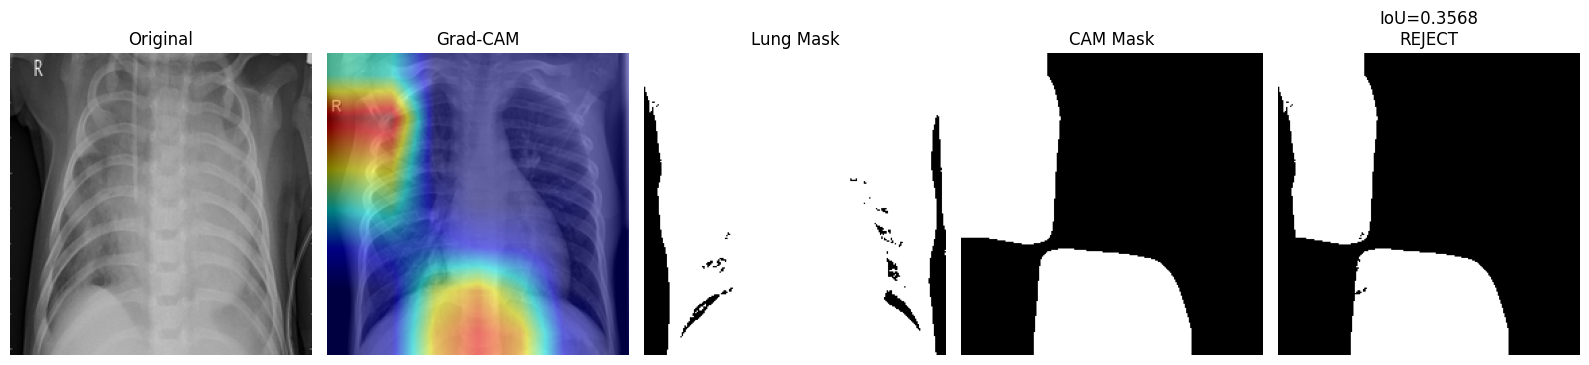

In [141]:
# ============================================================
# VISUALIZE FINAL VALIDATION RESULT
# ============================================================

visualize_validation_result(
    sample_path,
    conversational_result["validation_result"]
)

In [142]:
'''sample_path, sample_label = random.choice(test_dataset.samples)

true_label_name = test_dataset.classes[sample_label]

autonomous_result = run_autonomous_agent_loop(
    image_path=sample_path,
    true_label=true_label_name,
    max_retries=2
)'''

'sample_path, sample_label = random.choice(test_dataset.samples)\n\ntrue_label_name = test_dataset.classes[sample_label]\n\nautonomous_result = run_autonomous_agent_loop(\n    image_path=sample_path,\n    true_label=true_label_name,\n    max_retries=2\n)'

Sonucu görselleştir:

In [114]:
'''visualize_validation_result(
    sample_path,
    autonomous_result["validation_result"]
)'''

'visualize_validation_result(\n    sample_path,\n    autonomous_result["validation_result"]\n)'

In [125]:
'''# ============================================================
# FINAL DEMO CELL: Random Test Sample + Safe Agent Conversation
# ============================================================

import random
import matplotlib.pyplot as plt

try:
    from IPython.display import display, Markdown
    IPYTHON_AVAILABLE = True
except:
    IPYTHON_AVAILABLE = False


# ------------------------------------------------------------
# 1) SETTINGS
# ------------------------------------------------------------
# False = API/Gemini çağırmaz, kota hatası olmaz.
# True  = Gemini varsa gerçek LLM cevabı dener, hata olursa otomatik demo cevaba döner.
#USE_LIVE_LLM = False
USE_LIVE_LLM = True

CAM_THRESHOLD = 0.4
IOU_THRESHOLD = 0.4
MAX_RETRIES = 1   # kısa demo için 1 retry yeterli


# ------------------------------------------------------------
# 2) SAFE AGENT RESPONSE FUNCTION
# ------------------------------------------------------------
def safe_agent_response(agent_name, system_prompt="", user_prompt="", fallback_context=""):
    """
    Kota / API / model hatası olursa hücreyi durdurmaz.
    Hata durumunda gerçek tool sonuçlarına göre kısa demo agent cevabı üretir.
    """

    # -----------------------------
    # Optional live LLM call
    # -----------------------------
    if USE_LIVE_LLM:
        try:
            full_prompt = f"""
SYSTEM:
{system_prompt}

USER:
{user_prompt}

Please answer briefly and clearly.
"""
            response = model.generate_content(full_prompt)
            return response.text

        except Exception as e:
            print(f"\n[WARNING] {agent_name} live LLM call failed.")
            print("Reason:", str(e))
            print("Switching to safe demo response...\n")

    # -----------------------------
    # Safe fallback responses
    # -----------------------------
    if agent_name == "Coordinator Agent":
        return (
            "I will coordinate the analysis workflow. "
            "First, the Vision Agent will use the trained model for prediction. "
            "Then, the Explanation Agent will request Grad-CAM evidence. "
            "Finally, the Critic Agent will evaluate explanation reliability using IoU, "
            "Pointing Game, and Faithfulness before the Report Agent summarizes the result."
        )

    elif agent_name == "Vision Agent":
        return (
            "I received the Vision Tool output. "
            f"{fallback_context} "
            "This prediction is a model-based classification result and should not be interpreted as a clinical diagnosis. "
            "I am forwarding this result to the Explanation Agent for visual explanation."
        )

    elif agent_name == "Explanation Agent":
        return (
            "I generated a Grad-CAM-based explanation for the predicted class. "
            "The heatmap shows which image regions contributed most strongly to the model decision. "
            "I am sending this explanation to the Critic Agent for reliability validation."
        )

    elif agent_name == "Critic Agent":
        return (
            "I evaluated the explanation using quantitative reliability metrics. "
            f"{fallback_context} "
            "If the explanation has sufficient overlap with lung-related regions and the confidence decreases after masking important regions, "
            "the explanation can be considered more trustworthy. Otherwise, it should be interpreted cautiously."
        )

    elif agent_name == "Report Agent":
        return (
            "Final AI-assisted report: The system analyzed one randomly selected chest X-ray image using a multi-agent workflow. "
            f"{fallback_context} "
            "The Vision Tool produced the prediction, the Explanation Tool generated Grad-CAM evidence, "
            "and the Critic Agent evaluated the explanation reliability. "
            "This result is for research demonstration only and is not a clinical diagnosis."
        )

    else:
        return "Safe demo response generated."


# ------------------------------------------------------------
# 3) HELPER FUNCTION TO PRINT AGENT CONVERSATION
# ------------------------------------------------------------
def print_agent_message(sender, receiver, message):
    title = f"{sender} → {receiver}"

    if IPYTHON_AVAILABLE:
        display(Markdown(f"### {title}\n{message}"))
    else:
        print("\n" + "=" * 70)
        print(title)
        print("-" * 70)
        print(message)


# ------------------------------------------------------------
# 4) RUN RANDOM SAMPLE DEMO
# ------------------------------------------------------------
print("\nSTARTING FINAL RANDOM SAMPLE DEMO")
print("=" * 70)

# Random test image
sample_path, sample_label = random.choice(test_dataset.samples)
true_label_name = test_dataset.classes[sample_label]

print("Selected random test image:")
print("Image path:", sample_path)
print("True label:", true_label_name)


# ------------------------------------------------------------
# 5) COORDINATOR AGENT
# ------------------------------------------------------------
conversation = []

coordinator_msg = safe_agent_response(
    agent_name="Coordinator Agent",
    system_prompt=coordinator_prompt if "coordinator_prompt" in globals() else "",
    user_prompt="Start the multi-agent chest X-ray analysis workflow."
)

conversation.append(("Coordinator Agent", "Vision Agent", coordinator_msg))
print_agent_message("Coordinator Agent", "Vision Agent", coordinator_msg)


# ------------------------------------------------------------
# 6) VISION TOOL + VISION AGENT
# ------------------------------------------------------------
vision_result = run_vision_tool(sample_path)

vision_context = (
    f"Prediction: {vision_result['prediction']}, "
    f"Confidence: {vision_result['confidence']}, "
    f"True label: {true_label_name}."
)

vision_msg = safe_agent_response(
    agent_name="Vision Agent",
    system_prompt=vision_agent_prompt if "vision_agent_prompt" in globals() else "",
    user_prompt=vision_context,
    fallback_context=vision_context
)

conversation.append(("Vision Agent", "Explanation Agent", vision_msg))
print_agent_message("Vision Agent", "Explanation Agent", vision_msg)


# ------------------------------------------------------------
# 7) EXPLANATION + VALIDATION LOOP
# ------------------------------------------------------------
current_cam_threshold = CAM_THRESHOLD
final_validation_result = None
final_decision = None

for attempt in range(MAX_RETRIES + 1):

    print(f"\nEXPLANATION / VALIDATION ATTEMPT {attempt + 1}")
    print("-" * 70)
    print("Current CAM threshold:", current_cam_threshold)

    # Explanation Agent message
    explanation_msg = safe_agent_response(
        agent_name="Explanation Agent",
        system_prompt=explanation_agent_prompt if "explanation_agent_prompt" in globals() else "",
        user_prompt=f"Generate Grad-CAM explanation with CAM threshold {current_cam_threshold}."
    )

    conversation.append(("Explanation Agent", "Critic Agent", explanation_msg))
    print_agent_message("Explanation Agent", "Critic Agent", explanation_msg)

    # Validation Tool
    validation_result = run_validation_tool(
        image_path=sample_path,
        cam_threshold=current_cam_threshold,
        iou_threshold=IOU_THRESHOLD
    )

    final_validation_result = validation_result

    critic_context = (
        f"IoU: {validation_result['iou']}, "
        f"IoU Decision: {validation_result['iou_decision']}, "
        f"Pointing Game Hit: {validation_result['pointing_game_hit']}, "
        f"Faithfulness Drop: {validation_result['faithfulness_drop']}, "
        f"Original Confidence: {validation_result['original_confidence']}, "
        f"Masked Confidence: {validation_result['masked_confidence']}."
    )

    critic_msg = safe_agent_response(
        agent_name="Critic Agent",
        system_prompt=critic_agent_prompt if "critic_agent_prompt" in globals() else "",
        user_prompt=critic_context,
        fallback_context=critic_context
    )

    # Routing decision
    if validation_result["iou_decision"] == "ACCEPT":
        final_decision = "ACCEPT"
        conversation.append(("Critic Agent", "Report Agent", critic_msg))
        print_agent_message("Critic Agent", "Report Agent", critic_msg)
        break

    else:
        final_decision = "REJECT"
        conversation.append(("Critic Agent", "Explanation Agent", critic_msg))
        print_agent_message("Critic Agent", "Explanation Agent", critic_msg)

        if attempt < MAX_RETRIES:
            print("\nCritic rejected the explanation. Retrying with lower CAM threshold...")
            current_cam_threshold = max(0.1, round(current_cam_threshold - 0.1, 2))
        else:
            print("\nMaximum retry reached. Moving to final report with cautious interpretation.")


# ------------------------------------------------------------
# 8) REPORT AGENT
# ------------------------------------------------------------
report_context = (
    f"True label: {true_label_name}. "
    f"Predicted label: {final_validation_result['prediction']}. "
    f"Confidence: {final_validation_result['confidence']}. "
    f"IoU: {final_validation_result['iou']}. "
    f"IoU decision: {final_validation_result['iou_decision']}. "
    f"Pointing Game Hit: {final_validation_result['pointing_game_hit']}. "
    f"Faithfulness Drop: {final_validation_result['faithfulness_drop']}. "
    f"Final system decision: {final_decision}."
)

report_msg = safe_agent_response(
    agent_name="Report Agent",
    system_prompt=report_agent_prompt if "report_agent_prompt" in globals() else "",
    user_prompt=report_context,
    fallback_context=report_context
)

conversation.append(("Report Agent", "User / Researcher", report_msg))
print_agent_message("Report Agent", "User / Researcher", report_msg)


# ------------------------------------------------------------
# 9) SUMMARY OUTPUT
# ------------------------------------------------------------
print("\nFINAL NUMERIC SUMMARY")
print("=" * 70)
print("True Label:", true_label_name)
print("Prediction:", final_validation_result["prediction"])
print("Confidence:", final_validation_result["confidence"])
print("IoU:", final_validation_result["iou"])
print("IoU Decision:", final_validation_result["iou_decision"])
print("Pointing Game Hit:", final_validation_result["pointing_game_hit"])
print("Faithfulness Drop:", final_validation_result["faithfulness_drop"])
print("Original Confidence:", final_validation_result["original_confidence"])
print("Masked Confidence:", final_validation_result["masked_confidence"])
print("Final Decision:", final_decision)


# ------------------------------------------------------------
# 10) VISUALIZE IMAGE + GRAD-CAM + VALIDATION RESULT
# ------------------------------------------------------------
visualize_validation_result(
    image_path=sample_path,
    validation_result=final_validation_result
)


# ------------------------------------------------------------
# 11) SIMPLE METRIC BAR PLOT
# ------------------------------------------------------------
metric_names = [
    "Confidence",
    "IoU",
    "Pointing Hit",
    "Faithfulness Drop"
]

metric_values = [
    final_validation_result["confidence"],
    final_validation_result["iou"],
    final_validation_result["pointing_game_hit"],
    final_validation_result["faithfulness_drop"]
]

plt.figure(figsize=(8, 4))
plt.bar(metric_names, metric_values)
plt.ylim(0, 1)
plt.title("Final Random Sample Metrics")
plt.ylabel("Score")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()'''

'# ============================================================\n# FINAL DEMO CELL: Random Test Sample + Safe Agent Conversation\n# ============================================================\n\nimport random\nimport matplotlib.pyplot as plt\n\ntry:\n    from IPython.display import display, Markdown\n    IPYTHON_AVAILABLE = True\nexcept:\n    IPYTHON_AVAILABLE = False\n\n\n# ------------------------------------------------------------\n# 1) SETTINGS\n# ------------------------------------------------------------\n# False = API/Gemini çağırmaz, kota hatası olmaz.\n# True  = Gemini varsa gerçek LLM cevabı dener, hata olursa otomatik demo cevaba döner.\n#USE_LIVE_LLM = False\nUSE_LIVE_LLM = True\n\nCAM_THRESHOLD = 0.4\nIOU_THRESHOLD = 0.4\nMAX_RETRIES = 1   # kısa demo için 1 retry yeterli\n\n\n# ------------------------------------------------------------\n# 2) SAFE AGENT RESPONSE FUNCTION\n# ------------------------------------------------------------\ndef safe_agent_response(agent_nam